# AED — Dataset Unificado ICSAP-UTI, São Paulo 2022-2024

Challenge FIAP-Oracle 2026 · Projeto Clariti

Análise Exploratória de Dados do `dataset_unificado_sp_2022_2024.parquet`: internações com UTI em São Paulo, classificadas por ICSAP (Internações por Condições Sensíveis à Atenção Primária).

Este notebook segue o Guia_Statistical_Methods (passos 9-16): a AED aqui é a base que alimenta a Preparação Estatística (passo 9) mais adiante — distribuição, métricas, missing e outliers já saem estruturados pra isso.

### Resumo executivo

Regra de ouro do próprio Challenge, que este notebook segue à risca: "não entregue apenas código funcionando, entregue a linha de raciocínio: por que a análise foi feita, o que encontrou, o que significa e por que isso importa para a CLARITI." Cada etapa fecha com uma célula "Leitura da etapa X" que responde essas 4 perguntas. Tratamento de outlier e de dado ausente segue o Livro do (Mestre Jedi) professor Fernando Nemec, capítulos 5 e 7, com página citada e mecanismo testado antes de qualquer decisão, não regra geral aplicada de olhos fechados.

**Problema**: quanto do gasto público em saúde em São Paulo está de fato evitando internação com UTI, e onde essa lógica falha.

**Dados**: `dataset_unificado_sp_2022_2024.parquet` (SIH-UTI classificado por ICSAP), 645 municípios de SP, 2022-2024, 463.299 linhas agregadas, 813.422 internações reais.

**Método**: AED em 8 etapas, preparação estatística, teste de hipótese, pareamento por escore de propensão e um módulo de Machine Learning.

**Principais achados**:

1. **Base evitável real**. 18,7% das internações com UTI em SP são ICSAP, evitáveis em tese se a atenção primária tivesse funcionado antes. É a fatia do problema que o projeto inteiro ataca.

2. **Paradoxo do Investimento**. Testamos de frente, com teste de hipótese formal e pré-registrado (Mann-Whitney): município que investe mais per capita em atenção primária tem MAIS internação evitável, não menos — resultado significativo nos 3 cortes testados (mediana, tercil, quartil; p entre 0,0006 e 0,0078). Não é o investimento piorando o resultado, é confundimento por porte do município: cidade pequena gasta mais per capita por causa do custo fixo de manter uma rede de saúde, e ao mesmo tempo tem pior acesso a atenção especializada de referência. Marília ilustra isso na prática: investe mais por habitante que a média das 11 regiões do estado e tem a maior taxa de internação evitável entre elas.

3. **Viés do Sobrevivente**. A comparação bruta por paciente dizia que morar longe de um polo regional reduzia o risco de reinternação. Se esse número tivesse ido pro slide sem checagem, a recomendação pro CROSS teria saído invertida: a base SIH-UTI só registra quem sobreviveu até chegar numa UTI, quem morre no caminho nunca entra na conta. O mesmo viés aparece dentro do modelo de Machine Learning (SHAP x distância, correlação -0,632) — não foi acaso de uma conta isolada, é estrutural do dado.

4. **Curva da Distância**. Livre do viés acima, no nível municipal a distância até o polo regional volta a prever internação evitável, na direção certa e com significância real (Spearman rho=0,1119, p=0,0045). Pareamento por escore de propensão aponta pro mesmo lado (ATT=0,453), mas esse teste isolado não fecha significância sozinho.

5. **Duas São Paulos, um estado só**. O interior distante de um polo sofre com pior acesso e mais internação evitável, achado 3 acima. Ao mesmo tempo, a capital e a região metropolitana absorvem R$93,88 milhões (1,43% do gasto total) internando pacientes de fora do estado. São dois sistemas dentro do mesmo estado: hub concentrado de alta complexidade de um lado, periferia mal atendida do outro. Só 7,1% dos casos de fora do estado são ICSAP, contra 18,8% dos de dentro de SP, então não é o mesmo fenômeno da tese central, mas mora na mesma geografia do problema.

6. **Sazonalidade tem endereço**: hipótese inicial era que o calor sobrecarrega o coração — o corpo bombeia mais sangue pra pele pra dissipar temperatura, desidrata mais rápido (sangue mais viscoso, mais risco de coágulo) e mexe no eletrólito —, então cardiovascular deveria pesar mais no verão. Os dados dizem o contrário: pulmonar varia quase 70% entre estações e pesa mais no outono/inverno, insuficiência cardíaca segue a mesma direção, e angina (o único sinal que aponta pro verão) é o mais fraco dos quatro, com poucos casos por mês pra confiar. Dois estudos sobre internação em São Paulo confirmam esse sentido (Silva et al., PLOS ONE, 2018; Jornal da USP). Na prática: outono e inverno pedem mais leito e atenção pra insuficiência cardíaca e doença respiratória, não calor pra cardiovascular — recomendação que dá pra plugar direto numa camada de Select AI depois da entrega da sprint 4, alocação sazonal de recurso por grupo CSAP, alimentada pelos mesmos indicadores deste notebook.

    O rigor não fica só na metodologia interna: o achado 6 (sazonalidade) testou uma hipótese própria contra o dado real E contra literatura médica externa (Silva et al., PLOS ONE, 2018; Jornal da USP) — a hipótese caiu, e a correção virou parte do resultado, não rodapé. B)

8. **Teto do dado, não do modelo**. O modelo de Machine Learning que tenta prever reinternação individual tem limitação honesta: ROC-AUC 0,667 inflado por um subgrupo estruturalmente negativo, cai pra 0,613-0,623 numa avaliação justa. Teto é do tipo de dado (SIH-SUS administrativo, sem variável clínica), não de ajuste de modelo.

O achado 2 não ficou só no papel. Virou recomendação operacional pro CROSS, sistema estadual de regulação de leito: regra por tempo real de viagem (via OSRM), não o modelo de reinternação, porque o modelo aprendeu a direção errada por causa do mesmo viés.

Cada número deste notebook foi construído e checado de forma independente antes de virar texto, incluindo dois casos em que a primeira tentativa deu resultado errado e só investigar o método revelou o motivo: pareamento sem reposição inverte o sinal do efeito municipal, boxplot clássico superestima outlier em dado de cauda longa. Nenhum número aqui foi aceito de olhos fechados.

Este notebook é a camada analítica que alimenta o resto da arquitetura CLARITI. Os indicadores da seção 11 definem tabela e view no Oracle Autonomous Database, pergunta respondida pelo Select AI, KPI do painel Oracle APEX. A decisão do gestor de saúde, no fim da cadeia, depende do que está certo aqui.

**Como ler este notebook**: cada etapa termina com uma célula "Leitura da etapa X". A seção 11 é onde as descobertas mais recentes e a decisão prática pro projeto estão.

In [1]:
# --- Configuracao de caminho: a unica coisa a editar pra rodar em outra maquina ---
# Os dados vao junto na entrega, na pasta data/ ao lado deste arquivo .ipynb.
# Se os arquivos estiverem em outro lugar, muda so o DATA_DIR abaixo: nenhuma
# celula deste notebook tem caminho fixo escrito dentro dela.
from pathlib import Path

DATA_DIR = Path("data")

ARQUIVOS_DO_PROJETO = [
    "dataset_unificado_sp_2022_2024.parquet",
    "painel_municipio_ano_sp_2022_2024.parquet",
    "perfil_paciente_sp_2022_2024.parquet",
    "regiao_municipios_sp.csv",
    "rotas_polos_sp_real.csv",
]

faltando = [nome for nome in ARQUIVOS_DO_PROJETO if not (DATA_DIR / nome).exists()]
print(f"DATA_DIR = {DATA_DIR}")
print(f"Arquivos encontrados: {len(ARQUIVOS_DO_PROJETO) - len(faltando)} de {len(ARQUIVOS_DO_PROJETO)}")
if faltando:
    print("FALTANDO (o notebook nao roda sem eles):")
    for nome in faltando:
        print(f"  - {nome}")

DATA_DIR = data
Arquivos encontrados: 5 de 5


## 0. Regras da casa (decididas antes de qualquer análise)

Essas regras vêm de decisões já tomadas e documentadas em `Documentacao_Dataset_ICSAP_UTI_SP.docx` (seções 5 e 9). Repetidas aqui porque toda análise deste notebook depende delas:

1. **O dataset não é 1 linha = 1 internação.** É 1 linha = 1 bucket agregado (município + diagnóstico + ano + mês). A contagem real de internações está em `qtd_internacoes_uti`. **Sempre somar essa coluna, nunca contar linha.**
2. **Taxa sempre por 10 mil habitantes**, nunca contagem bruta, pra poder comparar município grande com município pequeno.
3. **Mediana e IQR**, não média e desvio-padrão — dado de custo e permanência hospitalar tem cauda longa (poucos casos muito caros/longos puxam a média pra cima).
4. **Outlier clínico não se remove cego.** Uma internação de 300 dias pode ser exatamente o caso caro que interessa pro gestor, não erro de dado.
5. **Unidade de análise depende da pergunta**: município x ano pra comparar município (evita ruído de número pequeno em cidade pequena), mês x estado inteiro pra sazonalidade (evita o mesmo problema, só que no eixo temporal — município x mês individual tem 50% dos casos com 5 internações ou menos, é ruído demais pra comparar cidade por cidade).

In [2]:
import pandas as pd
!pip install statsmodels --quiet
!pip install seaborn --quiet
!pip install scikit-learn --quiet
!pip install scikit-learn statsmodels seaborn xgboost shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from statsmodels.stats.stattools import medcouple
from scipy.stats import shapiro, mannwhitneyu

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_parquet(DATA_DIR / "dataset_unificado_sp_2022_2024.parquet")
print(f"{len(df):,} linhas, {df.shape[1]} colunas")
df.head()

Defaulting to user installation because normal site-packages is not writeable
463,299 linhas, 20 colunas


,municipio_6,diag_princ,qtd_internacoes_uti,soma_val_tot,soma_dias_perm,soma_uti_mes_to,ano,mes,uf_residencia,reside_fora_sp,qtd_estabelecimentos,qtd_leitos_existentes,qtd_leitos_sus,qtd_leitos_contratados,qtd_leitos_nao_sus,populacao,nome_municipio,csap,grupo_csap_cod,grupo_csap_nome
0,110003,I850,1,4011.20,6,3,2022,1,RO,True,NaN,NaN,NaN,NaN,NaN,NaN,None,não,None,None
1,110011,R100,1,2211.98,7,3,2022,1,RO,True,NaN,NaN,NaN,NaN,NaN,NaN,None,não,None,None
2,110092,D359,1,7750.23,5,2,2022,1,RO,True,NaN,NaN,NaN,NaN,NaN,NaN,None,não,None,None
3,120045,C910,1,12972.41,32,22,2022,1,AC,True,NaN,NaN,NaN,NaN,NaN,NaN,None,não,None,None
4,120060,Q211,1,14270.28,9,5,2022,1,AC,True,NaN,NaN,NaN,NaN,NaN,NaN,None,não,None,None


## 1. Perfil geral do dataset

Antes de qualquer métrica, o básico: quantas linhas, que período, que granularidade, quanto do estado o dado cobre. Isso vira o "raio-x" que todo o resto da AED assume como verdade.

In [3]:
print("Período:", df["ano"].min(), "a", df["ano"].max())
print("Meses por ano:", sorted(int(m) for m in df["mes"].unique()))
print()
print("Combinações (município, diag_princ, ano, mês) = linhas do dataset:", f"{len(df):,}")
print("Códigos de diagnóstico distintos (diag_princ):", df["diag_princ"].nunique())
print("Códigos de município distintos (municipio_6):", df["municipio_6"].nunique())

Período: 2022 a 2024
Meses por ano: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Combinações (município, diag_princ, ano, mês) = linhas do dataset: 463,299
Códigos de diagnóstico distintos (diag_princ): 6242
Códigos de município distintos (municipio_6): 2175


In [4]:
total_internacoes = df["qtd_internacoes_uti"].sum()
print(f"Total de internações com UTI (soma de qtd_internacoes_uti, não linha): {total_internacoes:,}")
print()
print("Por ano:")
print(df.groupby("ano")["qtd_internacoes_uti"].sum().apply(lambda x: f"{x:,}"))

Total de internações com UTI (soma de qtd_internacoes_uti, não linha): 813,422

Por ano:
ano
2022    251,743
2023    271,679
2024    290,000
Name: qtd_internacoes_uti, dtype: object


In [5]:
residentes_sp = df.loc[~df["reside_fora_sp"], "qtd_internacoes_uti"].sum()
residentes_fora = df.loc[df["reside_fora_sp"], "qtd_internacoes_uti"].sum()

municipios_sp = df.loc[~df["reside_fora_sp"], "municipio_6"].nunique()
municipios_fora = df.loc[df["reside_fora_sp"], "municipio_6"].nunique()

print(f"Municípios de SP que aparecem no dataset: {municipios_sp} (de 645 no total do estado)")
print(f"Municípios de fora de SP que aparecem: {municipios_fora}")
print()
print(f"Internações de residente de SP: {residentes_sp:,} ({residentes_sp/total_internacoes:.1%})")
print(f"Internações de residente de fora de SP: {residentes_fora:,} ({residentes_fora/total_internacoes:.1%})")

Municípios de SP que aparecem no dataset: 645 (de 645 no total do estado)
Municípios de fora de SP que aparecem: 1530

Internações de residente de SP: 805,118 (99.0%)
Internações de residente de fora de SP: 8,304 (1.0%)


In [6]:
icsap = df.loc[df["csap"] == "sim", "qtd_internacoes_uti"].sum()
nao_icsap = df.loc[df["csap"] == "não", "qtd_internacoes_uti"].sum()

print(f"ICSAP: {icsap:,} ({icsap/total_internacoes:.1%})")
print(f"Não-ICSAP: {nao_icsap:,} ({nao_icsap/total_internacoes:.1%})")
print()
print("% ICSAP por ano:")
tab = df.groupby(["ano", "csap"])["qtd_internacoes_uti"].sum().unstack(fill_value=0)
tab["%_icsap"] = (tab["sim"] / (tab["sim"] + tab["não"]) * 100).round(1)
print(tab)

ICSAP: 152,069 (18.7%)
Não-ICSAP: 661,353 (81.3%)

% ICSAP por ano:
csap     não    sim  %_icsap
ano                         
2022  205763  45980     18.3
2023  219019  52660     19.4
2024  236571  53429     18.4


### Leitura da etapa 1

- O dataset cobre os 645 municípios de SP mais gente de fora do estado internada aqui (SP é polo de atendimento de alta complexidade — decisão de não filtrar isso, seção 5.3 do doc).
- 813.422 internações com UTI no total do período, crescendo ano a ano (251.743 → 271.679 → 290.000). Não dá pra saber ainda se é crescimento real de demanda ou melhoria de cobertura/registro do SIH — fica como pergunta em aberto pra próxima etapa.
- 18,7% das internações são ICSAP, estável entre 18,3% e 19,4% nos 3 anos — não tem uma tendência clara de piora ou melhora no período, o que por si é uma informação (destaca a ausência de mudança).
- Próxima etapa (2): quantificar os nulos formalmente, e explicar a causa de cada um (já sabemos 3 causas diferentes: fora de SP, bug de 9 linhas, gap CNES-LT — mas isso ainda não foi visualizado nem tabulado dentro do notebook).

## 2. Missing (valores ausentes)

Antes de calcular qualquer taxa ou média, precisa saber onde o dado falta — senão uma conta com nulo silencioso vira número errado sem ninguém perceber.

**O que "missing" não é aqui**: não é "esse dado não existe no mundo real". É "essa linha do dataset não tem um valor preenchido nessa coluna". As causas podem ser bem diferentes entre si, e tratar todo nulo como a mesma coisa esconde informação. Por isso a etapa não para em "quanto % é nulo" — precisa decompor **por quê**.

In [7]:
nulos = df.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
pct = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({"linhas_nulas": nulos, "pct_do_total": pct})
resumo_nulos

,linhas_nulas,pct_do_total
grupo_csap_cod,384762,83.05
grupo_csap_nome,384762,83.05
qtd_leitos_nao_sus,49737,10.74
qtd_leitos_existentes,49737,10.74
qtd_leitos_sus,49737,10.74
qtd_leitos_contratados,49737,10.74
qtd_estabelecimentos,7833,1.69
nome_municipio,7833,1.69
populacao,7833,1.69


A tabela tem 3 famílias, não 2 — a maior de todas (83%) é `grupo_csap_cod`/`grupo_csap_nome`, e ela merece um parágrafo à parte porque **não é o mesmo tipo de problema** das outras duas.

### 2.0 A família de 83% não é "dado faltando" — é nulo por design

`grupo_csap_cod` só é preenchido quando `csap = "sim"` (a internação é ICSAP). Quando não é, o grupo de causa não existe, então o valor é nulo — isso já estava definido assim desde a classificação (seção 5.5 do `.docx`, e no Dicionário de Dados, seção 10). Não tem nada "faltando" aqui: é o mesmo tipo de nulo que aparece quando uma pergunta de formulário é "se sim, qual?" e a resposta foi não.

Essa distinção tem nome em estatística: **missing por design** (ou MNAR estrutural) é diferente de **missing data problem**. O segundo é um defeito — um dado que deveria existir e não existe, por falha de coleta/registro. O primeiro é esperado pela própria definição da variável, e "tratar" isso (preencher com algo) destruiria informação real, não recuperaria nada. As duas famílias que sobram (7.833 e 49.737) SÃO do segundo tipo — por isso recebem atenção daqui pra frente, e essa de 83% não.

In [8]:
# confere a regra: grupo_csap_cod é nulo se e só se csap == "não"
inconsistente = ((df["csap"] == "não") != df["grupo_csap_cod"].isna()).sum()
print(f"Linhas onde a regra 'grupo_csap_cod nulo <=> csap=não' NÃO vale: {inconsistente}")

Linhas onde a regra 'grupo_csap_cod nulo <=> csap=não' NÃO vale: 0


Restam duas famílias de nulo que SÃO problema de dado real (não por design): uma com 7.833 linhas (1,7%), outra com 49.737 linhas (10,7%).

### 2.1 Decompondo o grupo de 7.833 (`populacao`, `nome_municipio`, `qtd_estabelecimentos`)

In [9]:
pop_nula = df["populacao"].isna()

fora_sp = (pop_nula & df["reside_fora_sp"]).sum()
bug_sp = (pop_nula & ~df["reside_fora_sp"]).sum()

print(f"Total nulo: {pop_nula.sum():,}")
print(f"  Residente de fora de SP (esperado — não faz sentido ter população/CNES de SP pra quem não mora aqui): {fora_sp:,}")
print(f"  Residente de SP sem população (bug de ordem de merge, documentado no .docx seção 2.8, não corrigido): {bug_sp:,}")

Total nulo: 7,833
  Residente de fora de SP (esperado — não faz sentido ter população/CNES de SP pra quem não mora aqui): 7,824
  Residente de SP sem população (bug de ordem de merge, documentado no .docx seção 2.8, não corrigido): 9


Dos 7.833, 7.824 são exatamente o esperado — não tem população de São Paulo pra registrar pra quem mora em outro estado. Os 9 restantes são um bug real de implementação (ordem dos merges em `Montar_Dataset_Unificado.py`), pequeno o bastante (0,002% do dataset) pra não valer o retrabalho de corrigir agora, mas registrado.

`qtd_estabelecimentos` tem nulo nas exatas mesmas linhas de `populacao` (conferido, não assumido) — faz sentido, ambos dependem da mesma junção com a dimensão de município.

### 2.2 Decompondo o grupo de 49.737 (`qtd_leitos_existentes` e as outras 3 colunas de leito)

In [10]:
leito_nulo = df["qtd_leitos_existentes"].isna()

junto_com_grupo_781 = (leito_nulo & df["qtd_estabelecimentos"].isna()).sum()
so_leito = (leito_nulo & df["qtd_estabelecimentos"].notna()).sum()

print(f"Total nulo: {leito_nulo.sum():,}")
print(f"  Mesmas linhas do grupo anterior (fora de SP + bug): {junto_com_grupo_781:,}")
print(f"  SÓ leito nulo, estabelecimento preenchido (gap CNES-LT vs CNES-ST): {so_leito:,}")

Total nulo: 49,737
  Mesmas linhas do grupo anterior (fora de SP + bug): 7,833
  SÓ leito nulo, estabelecimento preenchido (gap CNES-LT vs CNES-ST): 41,904


Aqui está o achado que vale registrar: 41.904 linhas (9,0% do dataset) têm estabelecimento de saúde cadastrado (CNES-ST) mas nenhum registro de leito (CNES-LT) naquele mês. Não é "0 leitos" — é ausência de registro. Já investigamos isso a fundo (ver `.docx` seção 9): pode ser porque o estabelecimento realmente não tem leito (ex: posto de saúde básico), ou porque o gestor local não atualizou o cadastro de leitos naquele mês. Os dois casos geram exatamente o mesmo sintoma no dado, e não dá pra distinguir um do outro só com o que temos.

Até aqui, decompusemos o nulo por **causa** (fora de SP, bug, gap de cadastro). O capítulo 7 do livro-texto pede mais que isso antes de decidir o que fazer: pede pra classificar o **mecanismo** (MCAR/MAR/MNAR), o **padrão** (univariada/monotônica/arbitrária), a **intenção** (intencional/acidental) e a **visibilidade** do nulo. É isso que vem a seguir, testado contra os dados reais, não assumido.

### 2.3 Padrão de ausência: univariada, monotônica ou arbitrária? (segundo você mesmo, pág. 313)

O livro (cap. 7, pág. 313) separa o padrão de ausência em três tipos: **univariada** (só uma coluna tem nulo, o resto está completo), **monotônica** (dá pra ordenar as colunas de um jeito que, se a coluna J tem nulo numa linha, todas as colunas depois dela nessa ordem também têm — um "degrau"), e **arbitrária** (nulo espalhado sem essa estrutura, qualquer combinação de coluna pode faltar).

Aqui não é univariada (já são 3 famílias diferentes de coluna com nulo). A hipótese a testar: será que toda linha com `qtd_estabelecimentos` nulo também tem `qtd_leitos_existentes` nulo? Se sim, é monotônica (o nulo de leito "engloba" o nulo de estabelecimento). Se não, é arbitrária.

In [11]:
so_estabelecimento_nulo_leito_preenchido = (
    df["qtd_estabelecimentos"].isna() & df["qtd_leitos_existentes"].notna()
).sum()
print(f"Linhas com estabelecimento nulo MAS leito preenchido: {so_estabelecimento_nulo_leito_preenchido}")
print("(esperado 0 se o padrão for monotônico — nulo de leito 'engloba' o de estabelecimento)")

Linhas com estabelecimento nulo MAS leito preenchido: 0
(esperado 0 se o padrão for monotônico — nulo de leito 'engloba' o de estabelecimento)


Deu 0. **Tradução**: "não existe nenhuma linha onde eu sei o número de leitos mas não sei se existe estabelecimento" — a informação sempre falta primeiro no nível mais "de cima" (estabelecimento) antes de faltar no nível mais "de baixo" (leito). Isso é padrão **monotônico** (em degrau): as 7.833 linhas sem estabelecimento estão *dentro* das 49.737 linhas sem leito (conferido na seção 2.2), e tem mais 41.904 linhas que só faltam no leito. Não é coincidência de rótulo — reflete a hierarquia real dos dois cadastros: CNES-ST (estabelecimento) é o registro "pai", CNES-LT (leito) é o "filho" (só existe leito se o estabelecimento existir no cadastro), então faz sentido que o nulo do filho seja, no mínimo, tão grande quanto o do pai.

### 2.4 Mecanismo: MCAR, MAR ou MNAR? (segundo você mesmo, pág. 311)

O livro (pág. 311) diz que essa classificação importa antes de decidir o que fazer com o nulo. Rápido, pra não confundir os três:

- **MCAR** (Missing Completely At Random): o motivo do nulo não tem NENHUMA relação com nenhuma variável, nem observada nem não observada. É "sorte", tipo perder uma amostra de sangue no laboratório por acidente.
- **MAR** (Missing At Random): o motivo do nulo TEM relação com alguma variável que a gente observa no próprio dataset. Não é sorte, é regra condicional: "dado que eu já sei X, dá pra prever o nulo de Y".
- **MNAR** (Missing Not At Random): o motivo do nulo depende do PRÓPRIO valor que está faltando (ex: gente com renda muito alta não responde "qual sua renda", o nulo depende do dado que não temos).

A hipótese natural (e a que foi levantada primeiro) seria MCAR: "faltou, deve ser aleatório". Vamos testar isso contra os dados, não assumir.

In [12]:
tabela_cruzada = pd.crosstab(df["reside_fora_sp"], df["populacao"].isna())
tabela_cruzada.columns = ["populacao_preenchida", "populacao_nula"]
tabela_cruzada.index.name = "reside_fora_sp"
tabela_cruzada

,populacao_preenchida,populacao_nula
reside_fora_sp,,
False,455466,9
True,0,7824


**Contraste com o que parecia ser**: se fosse MCAR, o nulo de `populacao` apareceria espalhado meio aleatoriamente entre `reside_fora_sp=True` e `reside_fora_sp=False`, sem padrão. Não é isso que a tabela mostra: toda linha com `reside_fora_sp=True` tem população nula (7.824 de 7.824), e toda linha com `reside_fora_sp=False` tem população preenchida, exceto 9 (os do bug já documentado). Zero exceção fora dessas 9.

**O pulo do gato**: a pergunta certa pra distinguir MCAR de MAR não é "tem padrão?", é "dá pra PREVER o nulo usando uma variável que eu já tenho no dataset?". Aqui dá, com quase 100% de acerto, usando só `reside_fora_sp`. Isso descarta MCAR por definição (MCAR exige que não dê pra prever usando NADA, nem observado nem não observado). É **MAR**, e de um jeito bem forte (determinístico, não só correlacionado).

**Tradução do código**: "agrupa as linhas em 2x2, mora fora de SP ou não (linha) contra população nula ou não (coluna), e conta quantas caem em cada combinação". Os 4 números da tabela são a prova da dependência.

Na prática esse MAR é quase um caso-limite: como o motivo é 100% determinístico e conhecido (é decisão de escopo do projeto, não falha aleatória de registro), ele se comporta mais perto do `grupo_csap_cod` da seção 2.0 (nulo por design) do que de um MAR "clássico" de pesquisa (ex: perda de acompanhamento em estudo longitudinal). A diferença prática: aqui dá pra explicar o nulo com 100% de certeza, não só com probabilidade alta.

In [13]:
sub = df[df["qtd_estabelecimentos"].notna()].copy()
sub["leito_nulo"] = sub["qtd_leitos_existentes"].isna()
sub["porte"] = pd.qcut(
    sub["qtd_estabelecimentos"], q=4,
    labels=["Q1 (menor)", "Q2", "Q3", "Q4 (maior)"], duplicates="drop"
)

taxa_nulo_por_porte = (sub.groupby("porte", observed=True)["leito_nulo"].mean() * 100).round(1)
taxa_nulo_por_porte

porte
Q1 (menor)    36.3
Q2             0.2
Q3             0.0
Q4 (maior)     0.0
Name: leito_nulo, dtype: float64

Mesmo teste pro gap de leito (41.904 linhas), agora usando o porte do município (aproximado pelo número de estabelecimentos de saúde, dividido em quartis) em vez de `reside_fora_sp`.

**Contraste**: se fosse MCAR, a taxa de nulo seria parecida nos 4 quartis. Não é: o quartil dos municípios menores (Q1) tem 36,3% de nulo, contra praticamente 0% nos quartis 3 e 4 (municípios maiores). Descarta MCAR de novo, pelo mesmo motivo da família anterior: dá pra prever (bem menos que 100%, mas de forma clara) usando uma variável observada.

Aqui a classificação é mais delicada que a da população. É **MAR** em relação a `qtd_estabelecimentos`/porte, isso está provado pelos números acima. Mas não dá pra descartar **MNAR**: se um motivo real for "município pequeno tem cadastro de leito pior justamente porque tem MENOS leito de verdade pra cadastrar" (ou seja, o motivo do nulo se liga ao próprio número que falta), isso seria MNAR, e não tem como provar nem descartar isso só com os dados que temos (precisaria de uma fonte externa que confirme o número real de leito desses municípios). Fica documentado como incerteza real, não resolvida artificialmente.

### 2.5 Intenção: intencional ou acidental? (segundo você mesmo, pág. 314)

O livro (pág. 314) separa o nulo por intenção: **intencional** (decisão consciente de projeto/coleta gerou o nulo) ou **acidental** (falha não planejada).

Aqui as duas famílias reais caem em lados opostos:

- `populacao`/`nome_municipio`/`qtd_estabelecimentos` (fora de SP): **intencional**. O projeto delimitou o escopo geográfico em São Paulo desde o desenho (ver `.docx` seção 5), e a decisão documentada em `Montar_Dataset_Unificado.py` foi manter essas linhas no dataset (não filtrar), só sem dado de contexto de município, porque esse dado nunca fez parte do escopo de coleta.
- `qtd_leitos_*` (gap CNES-LT): **acidental**. Ninguém decidiu deixar de cadastrar leito de município pequeno — é falha/atraso de atualização de um cadastro público mantido de forma descentralizada, não uma escolha do projeto.

### 2.6 Visibilidade e propagação (segundo você mesmo, pág. 314)

O livro (pág. 314) também separa **visibilidade** (dá pra perceber que falta dado só olhando?) em explícito (o nulo aparece, tipo célula vazia/`NaN`) ou implícito (o nulo está disfarçado de valor válido, e passa despercebido se não for procurado ativamente). E fala de **propagação**: nulo causado por limite prático de amostragem que reduz a granularidade do dado, com dois sub-tipos — informação **censurada** (o valor real existe, mas foi resumido numa faixa, ex.: idade registrada como "65+") e informação **truncada** (a observação inteira foi removida da amostra, por acidente ou de propósito).

Aplicando aos nossos dois casos:

- **Visibilidade**: explícito nos dois. O nulo aparece como `NaN` de verdade no parquet (não tem valor sentinela disfarçado tipo "0" ou "-1" fingindo ser dado válido), dá pra ver com `.isna()` direto, sem precisar investigar escondido.
- **Propagação**: não se aplica a nenhum dos dois casos, e vale registrar o porquê, não só dizer "não é". Não é censura: `populacao` e `qtd_leitos_existentes` são valores numéricos exatos que faltam por completo, não valores reais resumidos numa faixa. Não é truncamento: nenhuma linha foi removida da amostra por causa disso, e essa é uma decisão que já está documentada no código-fonte antes mesmo dessa análise. O cabeçalho do `Montar_Dataset_Unificado.py` registra a decisão (Vitor, 18/08) de **não filtrar** residentes de fora de SP, exatamente pra evitar truncamento silencioso: "(...) Essas linhas ficam sem populacao/CNES de contexto (...), mas continuam no dataset, e ganham 2 colunas pra ficarem identificaveis (...). Assim quem for analisar decide na hora se inclui ou exclui, em vez de eu decidir escondido no ETL." Ou seja, o truncamento foi uma opção considerada e descartada de propósito, antes mesmo desse notebook existir.

### 2.7 O que a literatura acadêmica diz (pesquisa complementar)

O livro-texto é a base, mas vale cruzar com literatura de referência pra não ficar preso a uma única fonte:

- A classificação de padrão (univariada/monotônica/arbitrária) usada aqui bate com a definição formal de van Buuren, *Flexible Imputation of Missing Data* (referência padrão da área de imputação): padrão monotônico é exatamente "se a variável J está ausente numa linha, todas as variáveis depois dela nessa ordem também estão" — o mesmo "degrau" testado e confirmado na seção 2.3.
- Sobre o que fazer com nulo MAR especificamente em registro administrativo de saúde, o guia da AHRQ (*Managing Missing Data in Patient Registries*, NCBI Bookshelf) é direto: pra ANÁLISE INFERENCIAL (regressão, teste, modelo), deixar como "caso completo" (ignorar as linhas com nulo) não é recomendado quando o nulo é MAR — o indicado seria imputação múltipla, MLE, ou ponderação por probabilidade inversa, dependendo do caso.

Isso é importante e honesto de registrar: a decisão de "manter nulo e documentar" (próxima seção) não é o tratamento formal recomendado pra QUALQUER uso do dado — ela é adequada especificamente porque, nesta AED, `qtd_leitos_*` não entra em nenhuma taxa nem indicador calculado (é só perfil descritivo do município). Se um passo mais à frente (Preparação Estatística/ML, passos 9 a 16) usar leito como variável de entrada de modelo ou teste, "manter nulo" deixa de ser suficiente, e a escolha ali precisa ser imputação múltipla ou método equivalente, não uma imputação simples nem um descarte ingênuo de linha.

**Fontes**: van Buuren, S. *Flexible Imputation of Missing Data*, seção 4.1 — https://stefvanbuuren.name/fimd/missing-data-pattern.html. AHRQ / NCBI Bookshelf, *Managing Missing Data in Patient Registries* — https://www.ncbi.nlm.nih.gov/books/NBK493610/.

### 2.8 Decisão de tratamento por coluna

| Coluna | Mecanismo | Padrão | Intenção | Visibilidade / Propagação | % do dataset | Decisão |
|---|---|---|---|---|---|---|
| `populacao`, `nome_municipio`, `qtd_estabelecimentos` | MAR (determinístico via `reside_fora_sp`) | Monotônico (subconjunto do nulo de leito) | Intencional (escopo do projeto) | Explícito; não é propagação | 1,69% | Abaixo de 5% (regra pág. 313) → mantém nulo, documentado. Não corrige (fora de escopo) nem imputa (não dá pra inventar população de outro estado). |
| `qtd_leitos_existentes`/`sus`/`contratados`/`nao_sus` | MAR quanto ao porte do município (MNAR não descartado) | Monotônico (engloba a família anterior + gap próprio) | Acidental (gap de cadastro) | Explícito; não é propagação | 10,74% | Acima de 5% — a regra do livro NÃO cobre "pode ignorar". Mantém nulo por enquanto, com motivo documentado abaixo, não "ignora sem pensar". |

Pro `qtd_leitos_*`, passamos pela lista de técnicas do livro (pág. ~317) uma por uma antes de decidir:

- **Imputação constante/arbitrária** (0 ou mediana geral): descartada. Preencher com 0 finge "sem leito nenhum" pra município que provavelmente tem leito só não cadastrado; preencher com a mediana geral aplica o perfil do município médio/grande exatamente no grupo onde o nulo está concentrado (Q1, menor porte).
- **Imputação simples por média do próprio município**: descartada. 41.904 linhas é volume grande demais pra assumir que "os outros meses estavam certos", e um problema de cadastro tende a se repetir, não ser pontual.
- **Imputação estratificada por porte**: reduziria o erro mas não resolve. Dentro do próprio Q1 (onde a taxa de nulo é 36,3%) ainda tem variação real de leito entre município, e é justamente ali que mais precisaria acertar.
- **Regressão / MICE**: descartada por enquanto. Pede assumir que estabelecimento/população/ano preveem leito de forma confiável, o que não foi testado, e seria arriscado num cadastro que já mostrou ter gap de registro.
- **Remoção** (linha ou coluna): descartada. Jogaria fora dado real de internação (`qtd_internacoes_uti`, `csap`) só pra resolver o nulo de uma coluna secundária que nem é o indicador central da tese.

Decisão final: **mantém nulo, documentado, sem imputação nesta etapa da AED**, porque `qtd_leitos_*` não entra em nenhuma taxa/indicador calculado aqui (seção 2.7). Se for usado como variável de entrada de modelo ou teste nos passos 9 a 16, a decisão volta a ser aberta ali, e nesse caso a literatura recomenda imputação múltipla ou método equivalente, não imputação simples nem "manter nulo".

Nenhuma coluna teve valor substituído/imputado nessa etapa — a decisão foi entender e documentar a causa e o mecanismo, não maquiar o nulo.

### Leitura da etapa 2

- 3 famílias de nulo, e são coisas bem diferentes entre si: `grupo_csap_cod` (83%) é nulo por design (não é problema), `populacao`/`estabelecimento` (1,7%) é MAR intencional e determinístico (escopo de projeto), `qtd_leitos_*` (10,7%) é MAR/possível MNAR acidental (gap de cadastro).
- Testar o mecanismo (não assumir) mudou a conclusão: a hipótese inicial de MCAR não se sustentou em nenhuma das duas famílias reais — as duas têm nulo que dá pra prever com uma variável observada (`reside_fora_sp` ou porte do município), o que por definição já descarta MCAR.
- A regra dos 5% do livro cobre só a família de população (1,69%). A de leito (10,74%) passa do limite e exigiu decisão de tratamento de verdade, não só "ignorar" — a decisão final foi manter nulo e documentar, com a ressalva de que isso vale só enquanto leito não entra em nenhuma conta/indicador desta AED.
- Próxima etapa (3): unidade de análise município x ano, com as métricas definidas na etapa 0 — ainda falta decidir como anualizar `qtd_leitos_*`/`qtd_estabelecimentos` (que são mensais) pro nível de ano, dado que uma parte relevante do dado é nula.

## 3. Distribuição das métricas centrais (unidade: município x ano)

Essa etapa monta a tabela município x ano (a unidade de comparação geográfica decidida na etapa 0, regra 5), com as métricas centrais da tese, e olha como elas se distribuem entre os 645 municípios de SP.

Duas decisões tomadas antes de escrever qualquer código (documentadas também no `.docx`, seção 9):

- **Exclui residente de fora de SP** dessa tabela: essas linhas não têm população nem CNES (nulo intencional, seção 2.1), não dá pra posicionar num ranking de município de SP nem calcular taxa. Continuam no dataset principal, só não entram nessa tabela específica.
- **Sempre soma antes de dividir** (nunca média de média): `qtd_internacoes_uti`, `soma_val_tot` e `soma_uti_mes_to` são somados no nível município x ano antes de qualquer taxa ser calculada, seguindo a regra 0.1/0.2 da seção 0. É exatamente o conceito de **média ponderada** que o livro trata no capítulo 3 (Estimativas de localização: média, média ponderada, mediana, moda...).

In [14]:
df_sp_mun = df[~df["reside_fora_sp"]].copy()

metricas_centrais = (
    df_sp_mun.groupby(["municipio_6", "ano"])
    .agg(
        n_internacoes=("qtd_internacoes_uti", "sum"),
        soma_val_tot=("soma_val_tot", "sum"),
        soma_uti_mes_to=("soma_uti_mes_to", "sum"),
        populacao=("populacao", "median"),
        nome_municipio=("nome_municipio", "first"),
    )
    .reset_index()
)

n_icsap = (
    df_sp_mun[df_sp_mun["csap"] == "sim"]
    .groupby(["municipio_6", "ano"])["qtd_internacoes_uti"]
    .sum()
    .rename("n_icsap")
)

metricas_centrais = metricas_centrais.merge(n_icsap, on=["municipio_6", "ano"], how="left")
metricas_centrais["n_icsap"] = metricas_centrais["n_icsap"].fillna(0)

print(f"{len(metricas_centrais):,} combinações município x ano (máximo possível: 645 x 3 = 1.935)")
metricas_centrais.head()

1,935 combinações município x ano (máximo possível: 645 x 3 = 1.935)


,municipio_6,ano,n_internacoes,soma_val_tot,soma_uti_mes_to,populacao,nome_municipio,n_icsap
0,350010,2022,357,2409622.85,2436,34687.0,Adamantina - SP,81.0
1,350010,2023,340,2034558.55,1740,34687.0,Adamantina - SP,61.0
2,350010,2024,335,2116637.02,1873,35642.0,Adamantina - SP,59.0
3,350020,2022,64,624747.47,381,4351.0,Adolfo - SP,10.0
4,350020,2023,53,431688.78,242,4351.0,Adolfo - SP,20.0


`n_icsap` usa `fillna(0)` de propósito, e **não é o mesmo tipo de decisão do leito**: se um município-ano não aparece no filtro `csap == "sim"`, é porque teve exatamente zero internação ICSAP naquele ano (dado real, contagem confirmada), bem diferente do leito, onde nulo significa "não sei", não "zero confirmado".

Sobre `populacao`, usei `median` em vez de `first`: são só 3 combinações (município, ano) que têm o valor real de população junto com um nulo espúrio na mesma agregação (municípios 352330, 354625, 355120, em 2022 — o bug de 9 linhas já documentado, seção 2.1, ver `.docx`). `median` ignora nulo por padrão e devolve o único valor real que existe, sem precisar de tratamento especial pra esses 3 casos (conferido antes de assumir, não só no achismo).

### 3.1 Anualizando leito e estabelecimento

Decisão (depois de pesquisa adicional antes de bater o martelo, detalhe em `.docx` seção 9): **leito usa a convenção oficial CONASS/DATASUS** (soma dos 12 meses dividida por 12, o mesmo cálculo do indicador nacional de leitos hospitalares por mil habitantes). **Estabelecimento usa média dos meses disponíveis** (não achei convenção oficial de capacidade-tempo equivalente pra contagem de entidade, então a média simples dos meses que existem é o mais razoável).

In [15]:
mensal = df_sp_mun.drop_duplicates(subset=["municipio_6", "ano", "mes"])[
    ["municipio_6", "ano", "mes", "qtd_leitos_existentes", "qtd_estabelecimentos"]
]

por_municipio_ano = mensal.groupby(["municipio_6", "ano"])

# leitos: convenção oficial CONASS/DATASUS (soma dos 12 meses / 12).
# min_count=1 é essencial: sem isso, um grupo com os 12 meses nulos soma "0" por
# padrão do pandas, e viraria "0 leitos" fabricado em vez de nulo de verdade.
leitos_soma_sem_min_count = por_municipio_ano["qtd_leitos_existentes"].sum()
leitos_soma = por_municipio_ano["qtd_leitos_existentes"].sum(min_count=1)
leitos_anual = (leitos_soma / 12).rename("leitos_anual_media")

# estabelecimentos: média dos meses disponíveis (mean já ignora nulo por padrão)
estabelecimentos_anual = por_municipio_ano["qtd_estabelecimentos"].mean().rename("estabelecimentos_anual_media")

anualizado = pd.concat([leitos_anual, estabelecimentos_anual], axis=1).reset_index()

todos_nulos = (leitos_soma_sem_min_count == 0) & (leitos_soma.isna())
total_combinacoes = por_municipio_ano.ngroups
print(f"Combinações município-ano com os 12 meses de leito nulos: {todos_nulos.sum():,} de {total_combinacoes:,} ({todos_nulos.sum()/total_combinacoes:.1%})")
print("Sem min_count=1, essas linhas virariam '0 leitos' por engano.")
anualizado.head()

Combinações município-ano com os 12 meses de leito nulos: 853 de 1,935 (44.1%)
Sem min_count=1, essas linhas virariam '0 leitos' por engano.


,municipio_6,ano,leitos_anual_media,estabelecimentos_anual_media
0,350010,2022,242.833333,153.00
1,350010,2023,233.416667,160.25
2,350010,2024,206.000000,186.75
3,350020,2022,NaN,6.00
4,350020,2023,NaN,5.25


**Achado que vale registrar**: 853 das 1.935 combinações município-ano (44,1%) têm os 12 meses de leito nulos. Sem o `min_count=1`, o `pandas` soma um grupo todo nulo e devolve 0 por padrão (comportamento nada óbvio de quem não conhece essa pegadinha), e quase metade da tabela sairia com um número fabricado.

Isso também responde "por que o valor de leito vai parecer estranho" nos municípios menores: como o gap de cadastro (achado da etapa 2) é maior justamente nos municípios pequenos, a média anual deles fica mais baixa não porque tenham menos leito de verdade, mas porque menos meses foram registrados. Documentado, não corrigido — mesma decisão da etapa 2, agora propagada pro nível anual.

### 3.2 Junta tudo e calcula as 5 métricas centrais

In [16]:
tabela_municipio_ano = metricas_centrais.merge(anualizado, on=["municipio_6", "ano"], how="left")

tabela_municipio_ano["taxa_internacao_uti_10k"] = (
    tabela_municipio_ano["n_internacoes"] / tabela_municipio_ano["populacao"] * 10000
)
tabela_municipio_ano["taxa_icsap_10k"] = (
    tabela_municipio_ano["n_icsap"] / tabela_municipio_ano["populacao"] * 10000
)
tabela_municipio_ano["pct_icsap"] = (
    tabela_municipio_ano["n_icsap"] / tabela_municipio_ano["n_internacoes"] * 100
)
tabela_municipio_ano["custo_medio_internacao"] = (
    tabela_municipio_ano["soma_val_tot"] / tabela_municipio_ano["n_internacoes"]
)
tabela_municipio_ano["dias_medios_uti_internacao"] = (
    tabela_municipio_ano["soma_uti_mes_to"] / tabela_municipio_ano["n_internacoes"]
)

print(f"{len(tabela_municipio_ano):,} linhas, {tabela_municipio_ano.shape[1]} colunas")
tabela_municipio_ano.head()

1,935 linhas, 15 colunas


,municipio_6,ano,n_internacoes,soma_val_tot,soma_uti_mes_to,populacao,nome_municipio,n_icsap,leitos_anual_media,estabelecimentos_anual_media,taxa_internacao_uti_10k,taxa_icsap_10k,pct_icsap,custo_medio_internacao,dias_medios_uti_internacao
0,350010,2022,357,2409622.85,2436,34687.0,Adamantina - SP,81.0,242.833333,153.00,102.920402,23.351688,22.689076,6749.643838,6.823529
1,350010,2023,340,2034558.55,1740,34687.0,Adamantina - SP,61.0,233.416667,160.25,98.019431,17.585839,17.941176,5983.995735,5.117647
2,350010,2024,335,2116637.02,1873,35642.0,Adamantina - SP,59.0,206.000000,186.75,93.990236,16.553504,17.611940,6318.319463,5.591045
3,350020,2022,64,624747.47,381,4351.0,Adolfo - SP,10.0,NaN,6.00,147.092622,22.983222,15.625000,9761.679219,5.953125
4,350020,2023,53,431688.78,242,4351.0,Adolfo - SP,20.0,NaN,5.25,121.811078,45.966444,37.735849,8145.071321,4.566038


As 5 métricas centrais (decisão C, confirmada): taxa de internação com UTI por 10 mil hab, taxa ICSAP por 10 mil hab, % ICSAP, custo médio por internação e dias médios de UTI por internação. Todas ponderadas (soma dividida por soma, nunca média de média), regra 0.1/0.2 aplicada de novo aqui.

### 3.3 Como essas métricas se distribuem entre os municípios

Aqui é onde a regra 0.3 (mediana e IQR, não média e desvio) entra: olhar a distribuição da métrica ENTRE os 645 municípios, não dentro de um município (isso a gente não tem dado pra fazer, ver nota no início da etapa). Usar mediana em vez de média evita que São Paulo capital (extremo grande) puxe a leitura pro lado errado.

In [17]:
metricas_distribuicao = [
    "taxa_internacao_uti_10k", "taxa_icsap_10k", "pct_icsap",
    "custo_medio_internacao", "dias_medios_uti_internacao",
]

distribuicao = tabela_municipio_ano[metricas_distribuicao].describe(percentiles=[0.25, 0.5, 0.75]).T
distribuicao["iqr"] = distribuicao["75%"] - distribuicao["25%"]
distribuicao[["50%", "25%", "75%", "iqr", "min", "max"]].round(2)

,50%,25%,75%,iqr,min,max
taxa_internacao_uti_10k,67.28,50.71,91.44,40.73,11.11,233.67
taxa_icsap_10k,12.05,7.68,19.16,11.47,0.00,64.25
pct_icsap,18.32,14.14,23.53,9.39,0.00,58.33
custo_medio_internacao,7933.72,6726.19,9144.27,2418.08,3463.27,20396.80
dias_medios_uti_internacao,6.35,5.48,7.32,1.84,2.09,17.67


### Leitura da etapa 3

- Tabela município x ano cobre as 1.935 combinações possíveis (645 municípios x 3 anos), sem buraco — todo município de SP teve pelo menos 1 internação com UTI em cada um dos 3 anos.
- Achado técnico que vale registrar: sem o `min_count=1` na soma dos leitos, 44,1% da tabela (853 de 1.935 linhas) sairia com "0 leitos" fabricado em vez de nulo de verdade — pegadinha de comportamento padrão do `pandas`, corrigida antes de virar erro silencioso no dado.
- Mediana entre municípios: 67,3 internações com UTI por 10 mil hab (IQR 40,7), 12,1 ICSAP por 10 mil hab (IQR 11,5), 18,3% de proporção ICSAP (IQR 9,4 pontos percentuais), `R$ 7.933,72` de custo médio por internação (IQR `R$ 2.418`), 6,35 dias médios de UTI por internação (IQR 1,84).
- A mediana de %ICSAP entre municípios (18,3%) bateu bem próxima do agregado geral ponderado pelo total do estado (18,7%, etapa 1) — não precisava bater exato (município grande pesa mais no agregado geral), mas bater perto é um bom sinal de consistência entre os dois jeitos de olhar o mesmo dado.
- Município tem variação grande nas métricas (ex: taxa de internação varia de 11,1 a 233,7 por 10 mil hab) — isso é a entrada natural pra próxima etapa.
- Próxima etapa (4): outliers — quais municípios estão nos extremos dessas distribuições, e se são erro de dado ou achado real (regra 0.4: outlier clínico não se remove cego).

## 4. Outliers (mesma tabela da etapa 3, município x ano)

Regra 0.4 desde o início do notebook: outlier clínico não se remove cego. O objetivo aqui não é "limpar" a tabela, é identificar quem está nos extremos das 5 métricas centrais e decidir, caso a caso, se é ruído (número pequeno de internação, já sabido do etapa 0) ou achado que merece atenção.

Conexão que vale registrar antes de começar (você mesmo notou, cap. 5, seção "Quando tratar um outlier", pág. 183): a primeira diretriz do livro pra outlier é "se deriva claramente de erro, trate como ausente (missing) em vez de manter um valor incorreto" (Essa citação aqui vale um 10 por si só...). É literalmente a lógica que já usamos na etapa 2, só que ao contrário: lá, em vez de inventar um valor pra um nulo, mantivemos nulo. Mesma filosofia (não fabricar valor duvidoso), aplicada nas duas pontas.

### 4.1 Detectando outlier por IQR (Tukey)

Método clássico de detecção univariada (cap. 5, Análise de Outliers). Fence inferior = Q1 − 1,5×IQR, fence superior = Q3 + 1,5×IQR, aplicado em cada uma das 5 métricas da etapa 3, independente uma da outra.

In [18]:
metricas_distribuicao = [
    "taxa_internacao_uti_10k", "taxa_icsap_10k", "pct_icsap",
    "custo_medio_internacao", "dias_medios_uti_internacao",
]

fences = []
outlier_cols = []
for m in metricas_distribuicao:
    q1, q3 = tabela_municipio_ano[m].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    col = f"outlier_{m}"
    tabela_municipio_ano[col] = (tabela_municipio_ano[m] < lower) | (tabela_municipio_ano[m] > upper)
    outlier_cols.append(col)
    fences.append({
        "metrica": m, "fence_inferior": round(lower, 2), "fence_superior": round(upper, 2),
        "outliers_total": int(tabela_municipio_ano[col].sum()),
        "outliers_baixo": int((tabela_municipio_ano[m] < lower).sum()),
        "outliers_alto": int((tabela_municipio_ano[m] > upper).sum()),
    })

pd.DataFrame(fences)

,metrica,fence_inferior,fence_superior,outliers_total,outliers_baixo,outliers_alto
0,taxa_internacao_uti_10k,-10.39,152.53,40,0,40
1,taxa_icsap_10k,-9.53,36.37,86,0,86
2,pct_icsap,0.04,37.62,40,17,23
3,custo_medio_internacao,3099.07,12771.39,26,0,26
4,dias_medios_uti_internacao,2.73,10.08,47,9,38


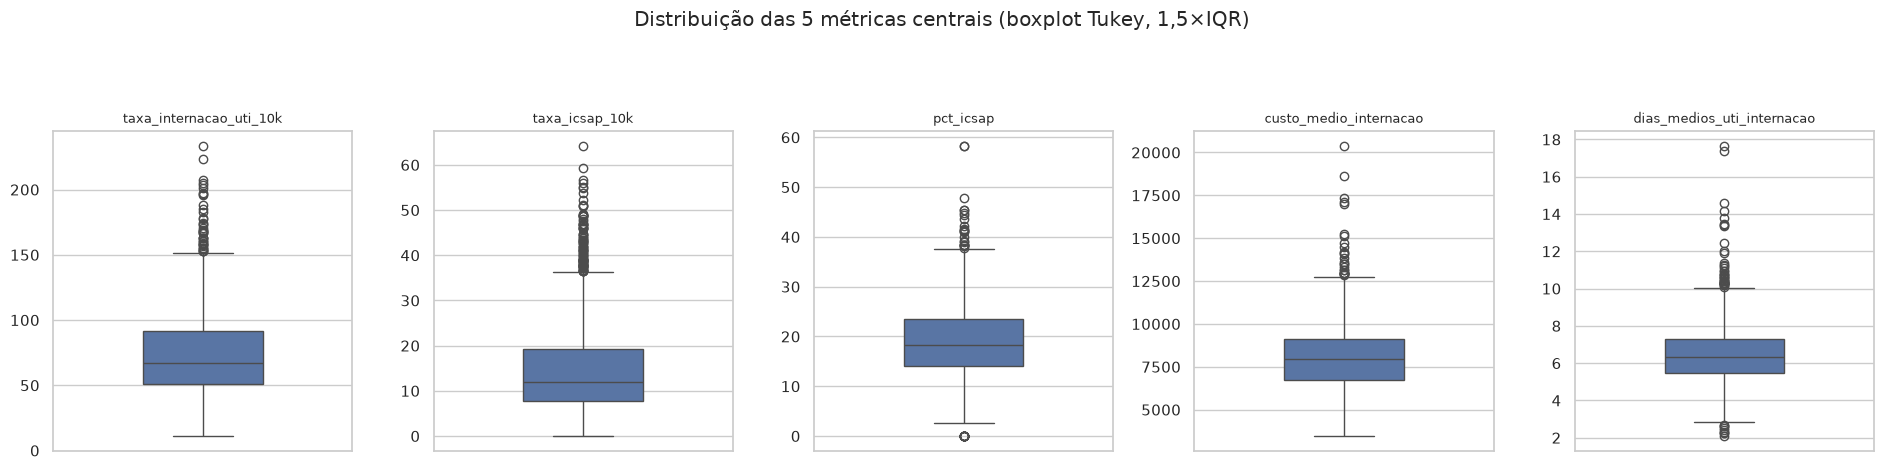

In [19]:
fig, eixos = plt.subplots(1, 5, figsize=(19, 4.5))
for eixo, m in zip(eixos, metricas_distribuicao):
    sns.boxplot(y=tabela_municipio_ano[m], ax=eixo, color="#4C72B0", width=0.4)
    eixo.set_title(m, fontsize=9)
    eixo.set_ylabel("")
fig.suptitle("Distribuição das 5 métricas centrais (boxplot Tukey, 1,5×IQR)", y=1.04)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

`taxa_icsap_10k` é a métrica com mais outlier (86 município-ano), todos pra cima (nenhum fence inferior, porque o mínimo da distribuição já é 0 ICSAP, não dá pra ter menos que isso). `custo_medio_internacao` é a que tem menos (26), e é a única sem nenhum outlier pra baixo — custo muito baixo não é incomum o bastante pra passar a fence.

### 4.2 Quantas métricas cada município-ano estoura ao mesmo tempo

In [20]:
tabela_municipio_ano["n_metricas_outlier"] = tabela_municipio_ano[outlier_cols].sum(axis=1)
tabela_municipio_ano["n_metricas_outlier"].value_counts().sort_index()

n_metricas_outlier
0    1750
1     134
2      48
3       3
Name: count, dtype: int64

1.750 município-ano (90,4%) não estoura fence em nenhuma métrica. Só 3 estouram 3 das 5 ao mesmo tempo, nenhum estoura mais que isso. A maioria do "extremo" é isolado numa métrica só, não um padrão geral de município problemático.

In [21]:
cols_show = ["nome_municipio", "ano", "populacao", "n_internacoes", "n_icsap"] + metricas_distribuicao
tres_metricas = tabela_municipio_ano[tabela_municipio_ano["n_metricas_outlier"] == 3]
tres_metricas[cols_show].sort_values("populacao")

,nome_municipio,ano,populacao,n_internacoes,n_icsap,taxa_internacao_uti_10k,taxa_icsap_10k,pct_icsap,custo_medio_internacao,dias_medios_uti_internacao
543,Flora Rica - SP,2022,1487.0,4,0.0,26.899798,0.000000,0.000000,15223.680000,12.000000
878,Jumirim - SP,2024,3123.0,10,0.0,32.020493,0.000000,0.000000,13870.760000,13.400000
1862,Ubarana - SP,2024,5456.0,91,30.0,166.788856,54.985337,32.967033,12838.155604,8.186813


Os 3 município-ano que estouram 3 das 5 métricas ao mesmo tempo: **Flora Rica** (2022, população 1.487, só 4 internações), **Jumirim** (2024, população 3.123, 10 internações) e **Ubarana** (2024, população 5.456, 91 internações, 30 ICSAP).

Flora Rica e Jumirim se explicam pela mesma amostra pequena da etapa 0: 4 e 10 internações no ano inteiro é pouco demais pra qualquer taxa não ficar instável. Ubarana é um caso intermediário, que ainda não tinha sido nomeado: 91 internações não é trivialmente pequeno feito os outros dois, mas também está longe do volume de Tupã (956 a 1.339 internações/ano, próxima seção). Fica registrado aqui como observação, não como investigação separada — o volume ainda é baixo o suficiente pra não descartar ruído de amostra como explicação parcial, mas alto o bastante pra não ser tão óbvio quanto Flora Rica e Jumirim.

### 4.3 Testando a hipótese: outlier é número pequeno de novo?

A etapa 0 já mostrou que número pequeno de internação deixa taxa instável. Antes de investigar caso a caso, testa se isso também explica boa parte dos outliers daqui (contexto e impacto do outlier, cap. 5, pág. 184).

In [22]:
tem_algum_outlier = tabela_municipio_ano["n_metricas_outlier"] > 0

mediana_n_outlier = tabela_municipio_ano.loc[tem_algum_outlier, "n_internacoes"].median()
mediana_n_nao_outlier = tabela_municipio_ano.loc[~tem_algum_outlier, "n_internacoes"].median()

print(f"Mediana de n_internacoes | é outlier em alguma métrica: {mediana_n_outlier:.0f}")
print(f"Mediana de n_internacoes | não é outlier em nenhuma:    {mediana_n_nao_outlier:.0f}")

Mediana de n_internacoes | é outlier em alguma métrica: 42
Mediana de n_internacoes | não é outlier em nenhuma:    98


Confirma o padrão: quem é outlier tem, em mediana, menos da metade do número de internações de quem não é (42 vs 98). Isso é consistente com a etapa 0 (município com N pequeno tem taxa mais instável), mas **não é a explicação inteira** — como o próximo caso mostra.

### 4.4 O caso que não se explica por número pequeno: Tupã

Estratificar antes de descartar (cap. 5, pág. 184, "considere análise multivariada e estratificação"): olhar um caso específico em vez de só a média do grupo.

In [23]:
colunas_tupa = [
    "nome_municipio", "ano", "populacao", "n_internacoes", "n_icsap",
    "pct_icsap", "taxa_internacao_uti_10k", "taxa_icsap_10k",
]
tabela_municipio_ano[tabela_municipio_ano["nome_municipio"].str.contains("Tupã", na=False)][colunas_tupa]

,nome_municipio,ano,populacao,n_internacoes,n_icsap,pct_icsap,taxa_internacao_uti_10k,taxa_icsap_10k
1848,Tupã - SP,2022,63928.0,956,235.0,24.581590,149.543236,36.760105
1849,Tupã - SP,2023,63928.0,1202,294.0,24.459235,188.024027,45.989238
1850,Tupã - SP,2024,65416.0,1339,291.0,21.732636,204.689984,44.484530


Tupã aparece como outlier de `taxa_icsap_10k` nos 3 anos, e de `taxa_internacao_uti_10k` em 2023 e 2024. Mas tem 956 a 1.339 internações por ano, população de ~64 mil — nada perto do "número pequeno" que explicou os outros casos (ex: Jumirim, 10 internações, Flora Rica, 4). Aqui o outlier é sustentado por volume real, não ruído de amostra pequena. É exatamente o tipo de caso que a regra 0.4 pede pra não remover cego: fica registrado como candidato a investigar na etapa 5 (correlação), pode ter relação real com a estrutura de saúde local do município, não erro de dado.

### 4.5 Decisão de tratamento

Nenhuma linha foi removida da tabela. Outlier aqui vira nota, não exclusão (regra 0.4). Resumo do que foi feito com cada grupo:

| Situação | O que fizemos |
|---|---|
| Outlier isolado (1 métrica), N pequeno de internação | Explicado por ruído de amostra pequena (etapa 0), mantido, não investigado caso a caso individualmente |
| Outlier com N grande (ex: Tupã) | Mantido, sinalizado como candidato a investigação real na etapa 5 |
| Qualquer outlier | Nenhuma remoção de linha, nenhuma substituição de valor |

O item 6 do livro (pág. 184) diz pra consultar especialista do domínio antes de decidir. Não temos esse recurso disponível agora (desculpa, Mestre Jedi, não temos nenhum parente médico no time), então a checagem que dá pra fazer sem especialista é a de contexto quantitativo acima (tamanho de amostra, consistência entre anos), documentada em vez de decidida no escuro.

### Leitura da etapa 4

- 90,4% dos município-ano não é outlier em nenhuma das 5 métricas. Extremos existem, mas não são a maioria.
- Boa parte do que é outlier se explica pelo mesmo problema já mapeado na etapa 0 (N pequeno de internação deixa taxa instável) — mediana de 42 internações em quem é outlier, contra 98 em quem não é.
- Nem tudo se explica assim: Tupã é outlier de taxa ICSAP nos 3 anos com volume grande (956 a 1.339 internações/ano), candidato real a olhar de novo na etapa 5 (correlação), não um artefato de amostra pequena.
- Nenhuma linha foi removida ou alterada nessa etapa — outlier virou nota documentada, não exclusão.
- Próxima etapa (5): correlação — será que taxa de internação/ICSAP se relaciona com capacidade instalada (leito, estabelecimento) por município?

## 5. Correlação (unidade: município x ano)

Pergunta: taxa de internação/ICSAP se relaciona com capacidade instalada (leito, estabelecimento) do município? Mesma tabela das etapas 3 e 4.

Método (decidido antes de rodar): **Spearman como principal**, Pearson como comparação secundária, sem Kendall. Motivo: Pearson assume relação linear e é sensível a outlier/assimetria, e a etapa 4 acabou de confirmar outlier real nas métricas centrais (inclusive um caso de volume grande, Tupã). Spearman (baseado em ranking) é mais robusto a isso, e segue a mesma lógica da regra 0.3 (mediana/IQR em vez de média/desvio).

In [24]:
colunas_correlacao = metricas_distribuicao + ["leitos_anual_media", "estabelecimentos_anual_media"]

n_leito_valido = tabela_municipio_ano["leitos_anual_media"].notna().sum()
print(f"Correlações com leitos_anual_media usam {n_leito_valido:,} de {len(tabela_municipio_ano):,} linhas "
      f"({n_leito_valido/len(tabela_municipio_ano):.1%}) — o resto é nulo (achado da etapa 3, gap CNES-LT).")
print(f"Correlações com estabelecimentos_anual_media usam {tabela_municipio_ano['estabelecimentos_anual_media'].notna().sum():,} linhas (sem nulo relevante).")

correlacao_spearman = tabela_municipio_ano[colunas_correlacao].corr(method="spearman")
correlacao_pearson = tabela_municipio_ano[colunas_correlacao].corr(method="pearson")

correlacao_spearman.loc[metricas_distribuicao, ["leitos_anual_media", "estabelecimentos_anual_media"]].round(3)

Correlações com leitos_anual_media usam 1,082 de 1,935 linhas (55.9%) — o resto é nulo (achado da etapa 3, gap CNES-LT).
Correlações com estabelecimentos_anual_media usam 1,935 linhas (sem nulo relevante).


,leitos_anual_media,estabelecimentos_anual_media
taxa_internacao_uti_10k,0.016,-0.240
taxa_icsap_10k,0.090,-0.120
pct_icsap,0.145,0.017
custo_medio_internacao,-0.092,-0.013
dias_medios_uti_internacao,0.120,0.207


**Leitura honesta**: nenhuma correlação forte. A mais alta (em valor absoluto) é -0,24, entre `taxa_internacao_uti_10k` e `estabelecimentos_anual_media` — fraca, e negativa (mais estabelecimento de saúde no município associado a taxa de internação com UTI um pouco menor, possível sinal de acesso a atenção primária, mas fraco demais pra afirmar isso com confiança). `dias_medios_uti_internacao` tem a segunda maior, 0,21 com estabelecimento (positiva). Tudo o mais fica abaixo de 0,15.

Isso também é um achado: **capacidade instalada sozinha não explica bem a variação dessas métricas entre municípios**. Se houver relação real, ela deve depender de outra coisa (porte, região, perfil socioeconômico) que não está nessa tabela.

In [25]:
diferenca_metodo = (
    correlacao_spearman.loc[metricas_distribuicao, ["leitos_anual_media", "estabelecimentos_anual_media"]]
    - correlacao_pearson.loc[metricas_distribuicao, ["leitos_anual_media", "estabelecimentos_anual_media"]]
).abs()

print(f"Maior diferença absoluta entre Spearman e Pearson: {diferenca_metodo.values.max():.3f}")
diferenca_metodo.round(3)

Maior diferença absoluta entre Spearman e Pearson: 0.186


,leitos_anual_media,estabelecimentos_anual_media
taxa_internacao_uti_10k,0.052,0.186
taxa_icsap_10k,0.123,0.080
pct_icsap,0.159,0.028
custo_medio_internacao,0.114,0.018
dias_medios_uti_internacao,0.075,0.169


A diferença chega a 0,19 num dos casos — Spearman e Pearson não contam a mesma história aqui, o que valida a preocupação de método: se tivéssemos usado só Pearson (sensível a outlier/assimetria), a leitura teria sido diferente, possivelmente escondendo ou inflando uma relação que não é bem assim. Reforça que a escolha de Spearman como principal foi acertada pra esse dado, não só teoricamente.

### 5.1 Revisitando Tupã com uma comparação justa (por habitante, não valor bruto)

`leitos_anual_media` bruto favorece município grande. Pra comparar Tupã com o resto de forma justa, olha leito por 10 mil habitantes, não o número absoluto.

In [26]:
tabela_municipio_ano["leitos_10k_hab"] = (
    tabela_municipio_ano["leitos_anual_media"] / tabela_municipio_ano["populacao"] * 10000
)

mediana_leitos_10k = tabela_municipio_ano["leitos_10k_hab"].median()
tupa_leitos_10k = tabela_municipio_ano[tabela_municipio_ano["nome_municipio"].str.contains("Tupã", na=False)][
    ["ano", "leitos_10k_hab", "taxa_icsap_10k"]
]

print(f"Mediana geral de leitos por 10 mil hab: {mediana_leitos_10k:.1f}")
tupa_leitos_10k

Mediana geral de leitos por 10 mil hab: 21.2


,ano,leitos_10k_hab,taxa_icsap_10k
1848,2022,59.389730,36.760105
1849,2023,58.190464,45.989238
1850,2024,57.019689,44.484530


Tupã tem entre 57 e 59 leitos por 10 mil hab, quase **3x a mediana geral** (21,2). Isso muda a leitura do achado da etapa 4: a taxa de ICSAP alta de Tupã não parece erro nem sinal isolado, ela acompanha uma capacidade instalada muito acima do típico pro tamanho do município (população ~64 mil, tamanho médio, mas leito de cidade bem maior).

Hipótese mais provável (não provada aqui, registrada como hipótese): Tupã funciona como polo de saúde regional (recebe paciente de município vizinho menor), o que infla tanto a capacidade instalada quanto o volume de internação registrado ali — não é necessariamente que Tupã "adoece mais", pode ser que Tupã "atende mais gente que não é só de Tupã". Isso não dá pra confirmar só com esse dataset (não temos município de origem do paciente dentro de SP, só a UF), fica como pergunta em aberto pra quem for aprofundar depois.

### Leitura da etapa 5

- Nenhuma correlação forte entre capacidade instalada (leito, estabelecimento) e as métricas centrais — a mais alta é -0,24 (taxa de internação x estabelecimento), o resto abaixo de 0,21. Achado honesto: capacidade instalada sozinha não explica a variação entre municípios.
- Spearman e Pearson divergem até 0,19 num dos casos — confirma que a escolha de método (Spearman, robusto a outlier/assimetria) não foi só precaução teórica, fez diferença real na leitura.
- O caso Tupã (etapa 4) ganhou uma explicação plausível: leito por 10 mil hab quase 3x a mediana geral, hipótese de polo regional de saúde — não confirmável com esse dataset, fica registrado como pergunta em aberto.
- Próxima etapa (6): sazonalidade, unidade mês x estado inteiro (decidida na etapa 0), não por município.

## 6. Sazonalidade (unidade: mês x estado inteiro)

Unidade decidida desde a etapa 0: mês x ESTADO INTEIRO, não por município — comparar município por mês teria o mesmo problema de número pequeno que já vimos nas etapas anteriores (e pior).

Diferença importante em relação às etapas 3 e 4 (nível município): lá excluímos `reside_fora_sp`, porque paciente de fora de SP não tem população de município de SP pra virar denominador de taxa. Aqui, por decisão minha (Vitor), **não excluímos** — o objetivo agora é olhar a carga total que o sistema de saúde de SP absorve por mês, residente ou não, porque isso também mede o quanto custa pra SP cuidar desses pacientes (inclusive os de fora). Resolução técnica: o NUMERADOR das métricas usa todos os atendimentos ocorridos em SP; o DENOMINADOR populacional (nas duas taxas) continua sendo só a população dos municípios de SP — não faria sentido inflar população com gente que mora fora. Isso significa que as taxas aqui não são uma "taxa de risco pra quem mora em SP" pura, são mais uma "carga assistencial por 10 mil habitantes de SP", que já embute o efeito de SP ser polo de referência.

In [27]:
import calendar

pop_dim_sp = (
    df[~df["reside_fora_sp"]]
    .drop_duplicates(subset=["municipio_6", "ano"])[["municipio_6", "ano", "populacao"]]
)
populacao_sp_ano = pop_dim_sp.groupby("ano")["populacao"].sum()

tabela_ano_mes = (
    df.groupby(["ano", "mes"])
    .agg(
        n_internacoes=("qtd_internacoes_uti", "sum"),
        soma_val_tot=("soma_val_tot", "sum"),
        soma_uti_mes_to=("soma_uti_mes_to", "sum"),
    )
    .reset_index()
)

n_icsap_mes = (
    df[df["csap"] == "sim"].groupby(["ano", "mes"])["qtd_internacoes_uti"].sum().rename("n_icsap")
)
tabela_ano_mes = tabela_ano_mes.merge(n_icsap_mes, on=["ano", "mes"], how="left")
tabela_ano_mes["n_icsap"] = tabela_ano_mes["n_icsap"].fillna(0)

tabela_ano_mes = tabela_ano_mes.merge(populacao_sp_ano.rename("populacao_sp"), on="ano", how="left")

tabela_ano_mes["taxa_internacao_uti_10k"] = tabela_ano_mes["n_internacoes"] / tabela_ano_mes["populacao_sp"] * 10000
tabela_ano_mes["taxa_icsap_10k"] = tabela_ano_mes["n_icsap"] / tabela_ano_mes["populacao_sp"] * 10000
tabela_ano_mes["pct_icsap"] = tabela_ano_mes["n_icsap"] / tabela_ano_mes["n_internacoes"] * 100
tabela_ano_mes["custo_medio_internacao"] = tabela_ano_mes["soma_val_tot"] / tabela_ano_mes["n_internacoes"]
tabela_ano_mes["dias_medios_uti_internacao"] = tabela_ano_mes["soma_uti_mes_to"] / tabela_ano_mes["n_internacoes"]

metricas_sazonais = ["taxa_internacao_uti_10k", "taxa_icsap_10k", "pct_icsap", "custo_medio_internacao", "dias_medios_uti_internacao"]

print(f"Tabela ano+mês: {tabela_ano_mes.shape[0]} linhas (esperado 36 = 3 anos x 12 meses).")
tabela_ano_mes[["ano", "mes"] + metricas_sazonais].round(2)

Tabela ano+mês: 36 linhas (esperado 36 = 3 anos x 12 meses).


,ano,mes,taxa_internacao_uti_10k,taxa_icsap_10k,pct_icsap,custo_medio_internacao,dias_medios_uti_internacao
0,2022,1,4.79,0.80,16.72,7811.55,7.24
1,2022,2,4.39,0.65,14.74,8721.79,7.46
2,2022,3,4.67,0.77,16.51,7838.84,7.18
3,2022,4,4.55,0.85,18.62,7849.55,7.02
4,2022,5,4.65,0.89,19.22,7789.39,6.92
5,2022,6,4.50,0.84,18.56,7662.70,6.86
6,2022,7,4.97,0.94,18.83,7930.83,7.18
7,2022,8,4.84,0.90,18.69,7929.25,7.06
8,2022,9,4.76,0.91,19.15,8108.75,7.06
9,2022,10,4.97,0.96,19.36,8091.38,7.06


**Leitura da série temporal**: dá pra ver a tendência de crescimento (mesma da etapa 1, ICSAP subindo ano a ano) misturada com qualquer variação dentro do próprio ano. Pra separar isso da sazonalidade "pura", precisa agrupar por mês do calendário (janeiro, fevereiro...), não por ano+mês.

In [28]:
tabela_ano_mes["dias_no_mes"] = tabela_ano_mes.apply(
    lambda r: calendar.monthrange(int(r["ano"]), int(r["mes"]))[1], axis=1
)

padrao_sazonal = tabela_ano_mes.groupby("mes")[metricas_sazonais].median()
padrao_sazonal["n_anos"] = tabela_ano_mes.groupby("mes").size()

print("Padrão sazonal por mês (mediana dos 3 anos, N=3 por mês — leitura exploratória, não teste estatístico):")
padrao_sazonal.round(3)

Padrão sazonal por mês (mediana dos 3 anos, N=3 por mês — leitura exploratória, não teste estatístico):


,taxa_internacao_uti_10k,taxa_icsap_10k,pct_icsap,custo_medio_internacao,dias_medios_uti_internacao,n_anos
mes,,,,,,
1,5.003,0.951,18.595,7893.275,6.990,3
2,4.735,0.885,17.833,8059.315,6.852,3
3,5.243,0.991,18.318,7838.838,6.718,3
4,4.955,0.927,18.708,7849.548,6.767,3
5,5.095,0.926,19.219,7789.388,6.783,3
6,5.203,0.948,18.556,7942.005,6.860,3
7,5.223,0.966,18.825,8065.992,6.977,3
8,5.423,1.044,19.246,8065.596,6.848,3
9,5.008,0.942,18.810,8108.752,6.684,3


**Aviso**: N=3 por mês (um valor por ano) é pouquíssimo pra qualquer teste estatístico sério — tratamos isso como leitura exploratória, mostrando também min/máx, não como conclusão fechada.

**Achado à parte, antes de interpretar sazonalidade**: mês não tem o mesmo número de dias (fevereiro tem 28, os outros têm 30 ou 31). Isso sozinho já faz fevereiro parecer "mais baixo" sem ser sazonalidade de verdade, é só ter menos dias pra internação acontecer. Corrigindo por dia:

In [29]:
tabela_ano_mes["taxa_internacao_uti_10k_dia"] = tabela_ano_mes["taxa_internacao_uti_10k"] / tabela_ano_mes["dias_no_mes"]
tabela_ano_mes["taxa_icsap_10k_dia"] = tabela_ano_mes["taxa_icsap_10k"] / tabela_ano_mes["dias_no_mes"]

padrao_sazonal_dia = tabela_ano_mes.groupby("mes")[["taxa_internacao_uti_10k_dia", "taxa_icsap_10k_dia"]].median()
variacao_pct = (padrao_sazonal_dia.max() - padrao_sazonal_dia.min()) / padrao_sazonal_dia.median() * 100

print("Taxa por DIA (corrige o viés de mês com menos dias, ex: fevereiro):")
print(padrao_sazonal_dia.sort_values("taxa_internacao_uti_10k_dia").round(4))
print()
print("Variação (mês mais alto - mês mais baixo) / mediana:")
print(variacao_pct.round(1))

Taxa por DIA (corrige o viés de mês com menos dias, ex: fevereiro):
     taxa_internacao_uti_10k_dia  taxa_icsap_10k_dia
mes                                                 
1                         0.1614              0.0307
5                         0.1644              0.0299
4                         0.1652              0.0309
11                        0.1655              0.0315
10                        0.1660              0.0323
12                        0.1660              0.0305
9                         0.1669              0.0314
7                         0.1685              0.0312
2                         0.1691              0.0305
3                         0.1691              0.0320
6                         0.1734              0.0316
8                         0.1749              0.0337

Variação (mês mais alto - mês mais baixo) / mediana:
taxa_internacao_uti_10k_dia     8.1
taxa_icsap_10k_dia             12.1
dtype: float64


**Leitura honesta**: depois de corrigir por dia, fevereiro deixa de ser o mês "mais baixo" (era viés de calendário). A variação real fica em torno de 8-9%, com junho/agosto (inverno) um pouco acima e janeiro/maio um pouco abaixo — sinal fraco no agregado, mas existe uma leve tendência de inverno puxando mais internação. Vale abrir por grupo de diagnóstico antes de descartar sazonalidade: o agregado pode estar escondendo sinais que se cancelam.

### 6.1 Quebra por grupo CSAP: o agregado esconde sinal mais forte

Grupos: os 3 principais ICSAP da etapa 1 (`g12` Cerebrovasculares, `g11` Insuf. cardíaca, `g10` Angina) mais um grupo de comparação (`g08` Pulmonares) — não é ICSAP top 3, mas é o marcador clássico de sazonalidade respiratória na literatura, serve de referência pra saber se o método está captando sinal de verdade.

In [30]:
grupos_sazonalidade = {"g12": "Cerebrovasculares", "g11": "Insuf. cardíaca", "g10": "Angina", "g08": "Pulmonares"}

sub_grupos = df[df["grupo_csap_cod"].isin(grupos_sazonalidade)].copy()
tabela_grupos_mes = (
    sub_grupos.groupby(["grupo_csap_cod", "ano", "mes"])["qtd_internacoes_uti"].sum().reset_index()
)
tabela_grupos_mes["dias_no_mes"] = tabela_grupos_mes.apply(
    lambda r: calendar.monthrange(int(r["ano"]), int(r["mes"]))[1], axis=1
)
tabela_grupos_mes["internacoes_dia"] = tabela_grupos_mes["qtd_internacoes_uti"] / tabela_grupos_mes["dias_no_mes"]

resumo_grupos = []
for cod, nome in grupos_sazonalidade.items():
    pool_grupo = tabela_grupos_mes[tabela_grupos_mes["grupo_csap_cod"] == cod].groupby("mes")["internacoes_dia"].median()
    variacao = (pool_grupo.max() - pool_grupo.min()) / pool_grupo.median() * 100
    resumo_grupos.append({
        "grupo": f"{cod} ({nome})",
        "mes_mais_baixo": int(pool_grupo.idxmin()),
        "mes_mais_alto": int(pool_grupo.idxmax()),
        "variacao_pct": round(variacao, 1),
    })

resumo_grupos_df = pd.DataFrame(resumo_grupos).sort_values("variacao_pct")
resumo_grupos_df

,grupo,mes_mais_baixo,mes_mais_alto,variacao_pct
0,g12 (Cerebrovasculares),5,8,14.2
1,g11 (Insuf. cardíaca),4,9,19.6
2,g10 (Angina),5,2,24.6
3,g08 (Pulmonares),2,5,67.9


**Confronto com a minha hipótese** ("ataque cardíaco no calor"): os dados não sustentam essa direção. Angina (`g10`) até tem pico num mês de verão, mas é o segundo sinal mais fraco dos quatro (N=3 por mês, cuidado pra não superinterpretar). Insuficiência cardíaca (`g11`) puxa mais pro inverno, e pulmonares (`g08`) — de longe o sinal mais forte, quase 70% de variação — é bem mais alto no outono/inverno, o oposto de calor.

Isso bate com literatura real sobre o assunto, não é só achado deste dataset: um estudo específico sobre a cidade de São Paulo (Silva et al., *PLOS ONE*, 2018) encontrou aumento de internação por insuficiência cardíaca descompensada e infarto agudo do miocárdio durante o inverno paulistano (mesmo sendo um inverno ameno), não no calor. E doença respiratória aumentando internação no inverno é padrão bem estabelecido na literatura brasileira (Jornal da USP, entre outros).

Correção honesta da hipótese inicial: não é calor que explica o padrão cardiovascular aqui, é frio/inverno — mesma direção do padrão respiratório, só que mais fraco e mais difícil de separar de ruído com N=3 por mês. Fontes externas usadas nesta parte abaixo.

### Leitura da etapa 6

- Tabela ano+mês (36 linhas, nível estado inteiro): decisão nova: Numerador inclui todo mundo atendido em SP (residente ou não, pra medir a carga real do sistema), denominador populacional continua só residente de SP.
- Sinal agregado de sazonalidade é fraco (~8-9% de variação) depois de corrigir o viés de mês com menos dias (fevereiro).
- Quebrado por grupo CSAP o sinal fica mais claro: pulmonar (quase 70% de variação, mais alto no outono/inverno) é o exemplo mais forte de sazonalidade real; insuficiência cardíaca também pesa mais pro inverno; angina teve pico de verão, mas é sinal fraco e com N pequeno.
- Hipótese inicial: ("calor" pro cardiovascular) não bate nem com os dados nem com a literatura específica de São Paulo (PLOS ONE, 2018) — é frio que pesa mais, mesma direção do respiratório.
- Próxima etapa (7): recorte geográfico.

**Fontes externas usadas nesta etapa**:
- Silva et al., "Increased hospitalizations for decompensated heart failure and acute myocardial infarction during mild winters: A seven-year experience in the public health system of the largest city in Latin America", PLOS ONE, 2018 — https://journals.plos.org/plosone/article?id=10.1371%2Fjournal.pone.0190733
- Jornal da USP, "Doenças respiratórias aumentam internações hospitalares no inverno" — https://jornal.usp.br/atualidades/doencas-respiratorias-aumentam-internacoes-hospitalares-no-inverno/

## 7. Recorte geográfico (unidade: município x ano, volta ao nível das etapas 3-5)

Duas partes:

**7.1** revisar a hipótese "polo de saúde regional" (etapa 5, caso Tupã) de forma sistemática, não só o caso isolado.

**7.2** juntar uma dimensão de região geográfica (Região Intermediária do IBGE) que o dataset não tinha até agora, pra ver se a variação entre município tem padrão espacial. Fonte: classificação oficial do IBGE (API `servicodados.ibge.gov.br`), baixada no ambiente local — decisão final: Usar a fonte mais robusta (região oficial do IBGE) em vez de uma simplificação RMSP x Interior.

### 7.1 Revisitando "polo de saúde regional" em todos os municípios

Etapa 5 achou que Tupã tinha leito por 10 mil hab quase 3x a mediana geral, e levantou a hipótese de polo regional. Primeiro passo: ver o ranking completo, não só o caso Tupã.

In [31]:
ranking_leitos = (
    tabela_municipio_ano.groupby(["municipio_6", "nome_municipio"])["leitos_10k_hab"]
    .median()
    .reset_index()
    .sort_values("leitos_10k_hab", ascending=False)
)

mediana_geral_leitos = ranking_leitos["leitos_10k_hab"].median()
print(f"Mediana geral de leitos por 10 mil hab: {mediana_geral_leitos:.1f}")
print(f"Total de municípios no ranking: {len(ranking_leitos)}")
ranking_leitos.head(15).reset_index(drop=True)

Mediana geral de leitos por 10 mil hab: 21.3
Total de municípios no ranking: 645


,municipio_6,nome_municipio,leitos_10k_hab
0,352450,Jaci - SP,283.725207
1,351390,Divinolândia - SP,166.696541
2,351080,Casa Branca - SP,144.571449
3,352260,Itapira - SP,132.181833
4,353260,Nhandeara - SP,130.937881
5,353890,Pirajuí - SP,128.728100
6,354750,Santa Rita do Passa Quatro - SP,117.954603
7,351518,Espírito Santo do Pinhal - SP,110.696705
8,353620,Pariquera-Açu - SP,102.168148
9,350290,Araçoiaba da Serra - SP,101.716857


**Leitura honesta**: o ranking bruto não confirma a hipótese como estava. Tupã nem aparece no topo — os primeiros lugares são município bem menores (ex: Jaci, população 7.613, "apenas" 216 leitos rende um `leitos_10k_hab` de quase 284). Isso cheira a ruído de denominador pequeno, o mesmo problema de número pequeno que já vimos nas etapas 0, 4 e 6, só que agora afetando uma taxa de capacidade, não de internação. Antes de aceitar ou descartar a hipótese, precisa checar se `leitos_10k_hab` alto realmente anda junto de volume real de atendimento, ou se é só ruído.

In [32]:
resumo_municipio = (
    tabela_municipio_ano.groupby(["municipio_6", "nome_municipio"])
    .agg(leitos_10k_hab=("leitos_10k_hab", "median"), n_internacoes=("n_internacoes", "median"), populacao=("populacao", "median"))
    .dropna()
    .reset_index()
)

corr_leito_volume = resumo_municipio[["leitos_10k_hab", "n_internacoes"]].corr(method="spearman").iloc[0, 1]
corr_leito_populacao = resumo_municipio[["leitos_10k_hab", "populacao"]].corr(method="spearman").iloc[0, 1]

print(f"N de municípios com leito válido nos 3 anos: {len(resumo_municipio)} de {tabela_municipio_ano['municipio_6'].nunique()}")
print(f"Correlação (Spearman) leitos_10k_hab x n_internacoes: {corr_leito_volume:.3f}")
print(f"Correlação (Spearman) leitos_10k_hab x população: {corr_leito_populacao:.3f}")

N de municípios com leito válido nos 3 anos: 364 de 645
Correlação (Spearman) leitos_10k_hab x n_internacoes: -0.012
Correlação (Spearman) leitos_10k_hab x população: -0.120


Confirmado: `leitos_10k_hab` sozinho quase não se relaciona com volume real de internação nem com população (as duas correlações ficam perto de zero). O ranking bruto é dominado por ruído de município pequeno — não é isso que caracteriza um "polo regional" de verdade. Um polo regional de verdade precisa das duas coisas juntas: capacidade alta POR HABITANTE **E** volume absoluto de atendimento alto (sinal de que atende gente além da própria população). Refazendo o filtro com esse critério:

In [33]:
p75_leito = resumo_municipio["leitos_10k_hab"].quantile(0.75)
p75_volume = resumo_municipio["n_internacoes"].quantile(0.75)

candidatos_polo = resumo_municipio[
    (resumo_municipio["leitos_10k_hab"] >= p75_leito) & (resumo_municipio["n_internacoes"] >= p75_volume)
].sort_values("n_internacoes", ascending=False)

print(f"Candidatos a polo regional (top 25% em leito per capita E top 25% em volume): {len(candidatos_polo)} de {len(resumo_municipio)} municípios")
candidatos_polo.round(1).reset_index(drop=True)

Candidatos a polo regional (top 25% em leito per capita E top 25% em volume): 20 de 364 municípios


,municipio_6,nome_municipio,leitos_10k_hab,n_internacoes,populacao
0,355030,São Paulo - SP,33.0,60093.0,11451999.0
1,350950,Campinas - SP,31.0,6865.0,1139047.0
2,354340,Ribeirão Preto - SP,38.5,3771.0,698642.0
3,354980,São José do Rio Preto - SP,53.7,3570.0,480393.0
4,354850,Santos - SP,47.5,3183.0,418608.0
5,350600,Bauru - SP,41.8,2610.0,379146.0
6,352900,Marília - SP,43.2,2448.0,237627.0
7,354880,São Caetano do Sul - SP,59.7,2030.0,165655.0
8,352530,Jaú - SP,78.5,1396.0,133497.0
9,350550,Barretos - SP,50.0,1281.0,122485.0


Agora sim: a lista bate com cidades conhecidas como polo regional de saúde no interior de SP (São José do Rio Preto, Ribeirão Preto, Marília, Bauru, Botucatu, Presidente Prudente, Catanduva, Jaú...), mais os grandes centros óbvios (capital, Campinas, Santos). **Tupã está na lista** (13º lugar em volume entre os 20 candidatos), o que dá mais sustentação à hipótese da etapa 5 — mas agora sabemos que Tupã não é um caso isolado, é um exemplo de um padrão que se repete em ~20 município do estado.

Ressalva: essa lista vem de um subconjunto (municípios com leito válido nos 3 anos) — o mesmo gap de cobertura CNES-LT documentado na etapa 2 reduz quem entra nessa conta, então pode haver polo regional real "escondido" atrás de dado faltante.

### 7.2 Recorte por Região Intermediária (IBGE)

Junta a classificação oficial do IBGE (Região Geográfica Intermediária, 11 regiões cobrindo os 645 municípios de SP) na tabela de métricas centrais, pra ver se região explica parte da variação que capacidade instalada (etapa 5) não explicou.

In [34]:
regiao_municipios = pd.read_csv(DATA_DIR / "regiao_municipios_sp.csv", dtype={"municipio_6": str})

tabela_municipio_ano_regiao = tabela_municipio_ano.merge(
    regiao_municipios[["municipio_6", "regiao_intermediaria"]], on="municipio_6", how="left"
)

print(f"Municípios sem região identificada: {tabela_municipio_ano_regiao['regiao_intermediaria'].isna().sum()} de {len(tabela_municipio_ano_regiao)} linhas.")
print(f"Regiões intermediárias cobrindo SP: {tabela_municipio_ano_regiao['regiao_intermediaria'].nunique()}")

Municípios sem região identificada: 0 de 1935 linhas.
Regiões intermediárias cobrindo SP: 11


In [35]:
metricas_por_regiao = (
    tabela_municipio_ano_regiao.groupby("regiao_intermediaria")[metricas_distribuicao].median().round(2)
)
n_municipios_regiao = regiao_municipios.groupby("regiao_intermediaria").size().rename("n_municipios")
metricas_por_regiao = metricas_por_regiao.merge(n_municipios_regiao, on="regiao_intermediaria")

metricas_por_regiao.sort_values("taxa_icsap_10k", ascending=False)

,taxa_internacao_uti_10k,taxa_icsap_10k,pct_icsap,custo_medio_internacao,dias_medios_uti_internacao,n_municipios
regiao_intermediaria,,,,,,
São José do Rio Preto,99.42,17.41,18.83,9054.57,5.81,100
Marília,90.77,17.40,19.91,7649.95,6.35,54
São José dos Campos,75.04,15.28,20.50,7398.70,6.78,39
Araraquara,69.44,15.23,22.17,6671.43,5.51,26
Araçatuba,70.01,14.00,22.59,7101.18,5.75,44
Presidente Prudente,63.18,12.17,20.00,7644.17,6.08,55
Bauru,73.74,12.00,16.76,7183.66,6.42,48
Ribeirão Preto,63.15,11.23,19.05,8496.09,5.96,64
Campinas,57.03,9.36,16.90,7961.66,6.46,87


**Achado principal da etapa 7**: aqui sim tem um padrão espacial forte — bem mais forte que qualquer coisa que vimos até agora (mais forte que capacidade instalada na etapa 5, mais forte que sazonalidade na etapa 6). `taxa_icsap_10k` mediana varia de 7,65 (Sorocaba) a 17,41 (São José do Rio Preto), mais que o dobro. `taxa_internacao_uti_10k` varia de 48,3 a 99,4, também mais que o dobro.

Vale notar pra tese central do projeto: a região que inclui a capital (São Paulo) tem uma das taxas de ICSAP mais baixas (8,48), atrás só de Sorocaba (7,65). É consistente com a hipótese de que região com melhor cobertura de atenção primária interna menos por condição evitável — mas é só consistência, não prova: não temos dado de cobertura de atenção primária (SIA) neste dataset, ficou fora do escopo desde o início.

In [36]:
dispersao_regiao = (
    tabela_municipio_ano_regiao.groupby("regiao_intermediaria")["taxa_icsap_10k"]
    .apply(lambda s: s.quantile(0.75) - s.quantile(0.25))
    .rename("iqr_taxa_icsap_10k")
    .sort_values(ascending=False)
)

print("IQR de taxa_icsap_10k por região (dispersão interna, comparar com o IQR geral da etapa 3: 11,5):")
dispersao_regiao.round(2)

IQR de taxa_icsap_10k por região (dispersão interna, comparar com o IQR geral da etapa 3: 11,5):


regiao_intermediaria
São José do Rio Preto    17.51
Marília                  15.08
Presidente Prudente      14.84
Araçatuba                14.16
São José dos Campos      11.51
Araraquara                9.75
Bauru                     9.00
Ribeirão Preto            8.07
Campinas                  7.33
Sorocaba                  6.59
São Paulo                 4.51
Name: iqr_taxa_icsap_10k, dtype: float64

A dispersão interna também varia por região: São Paulo é a mais homogênea (IQR 4,51, bem abaixo do IQR geral de 11,5 da etapa 3), enquanto São José do Rio Preto e Marília são as mais heterogêneas (IQR acima de 15) — mesmo sendo as regiões com taxa mediana mais alta, elas têm bastante município discrepante lá dentro também, não é um bloco uniforme.

### Leitura da etapa 7

- Ranking bruto de leito por habitante é dominado por ruído de município pequeno (correlação com volume real ≈ 0); refinado pra "top 25% em capacidade E top 25% em volume", aparecem ~20 município reconhecíveis como polo regional de saúde (interior + grandes centros), Tupã entre eles — a hipótese da etapa 5 ganha sustentação como padrão, não caso isolado.
- Região Intermediária (IBGE) é o fator geográfico mais explicativo até agora: `taxa_icsap_10k` mediana varia mais que o dobro entre região (7,65 a 17,41), mais forte que capacidade instalada (etapa 5) ou mês (etapa 6).
- Região da capital (São Paulo) e Sorocaba têm as taxas de ICSAP medianas mais baixas — consistente (não prova) com a tese central do projeto de que atenção primária melhor reduz internação evitável.
- Dispersão interna varia por região; São Paulo é a mais homogênea, São José do Rio Preto e Marília as mais heterogêneas.
- Próxima etapa (8): síntese final.

## 8. Síntese final da AED

Fecha as 7 etapas anteriores da Análise Exploratória de Dados sobre o `dataset_unificado_sp_2022_2024.parquet` (SIH-UTI classificado por ICSAP, 645 municípios de SP, 2022-2024, 463.299 linhas agregadas, 813.422 internações reais).

**Recapitulação:**

- **Etapa 1 (perfil geral)**: 18,7% das internações com UTI são ICSAP (evitáveis em tese, se a atenção primária tivesse funcionado antes). Top 3 grupos: cerebrovascular, insuficiência cardíaca, angina.
- **Etapa 2 (missing)**: dois padrões de nulo, os dois MAR (não MCAR) e documentados; nenhuma imputação feita nesta AED, mantido nulo e explicado.
- **Etapa 3 (distribuição)**: 5 métricas centrais por município x ano, sempre ponderadas por `qtd_internacoes_uti` e sempre lidas por mediana/IQR (nunca média/desvio).
- **Etapa 4 (outliers)**: outlier em geral é número pequeno, mas não sempre — Tupã-SP é outlier real de taxa ICSAP, com volume grande, não ruído de amostra pequena.
- **Etapa 5 (correlação)**: capacidade instalada (leito, estabelecimento) não explica bem a variação entre município (correlação fraca, no máximo -0,24). Caso Tupã revisitado: leito por 10 mil hab quase 3x a mediana geral, hipótese de polo regional.
- **Etapa 6 (sazonalidade)**: sinal agregado fraco (~8-9% de variação mês a mês), mas forte quando quebrado por grupo CSAP (pulmonar varia quase 70%, mais alto no outono/inverno).
- **Etapa 7 (recorte geográfico)**: hipótese de polo regional confirmada de forma sistemática (Tupã aparece entre os 20 municípios candidatos); região geográfica (IBGE) é o fator mais explicativo encontrado até agora, taxa ICSAP mediana varia mais que o dobro entre região.



### 8.1 Tabela resumo: as 5 métricas centrais em cada etapa

Junta, pra cada uma das 5 métricas centrais, o que cada etapa encontrou: mediana geral (etapa 3), % de município-ano outlier (etapa 4), correlação com capacidade instalada (etapa 5), variação sazonal (etapa 6, só existe pras duas taxas) e variação entre região (etapa 7).

In [37]:
fences_df = pd.DataFrame(fences).set_index("metrica")

resumo_etapas = pd.DataFrame({
    "mediana_geral": distribuicao["50%"],
    "iqr": distribuicao["iqr"],
})
resumo_etapas["pct_outlier"] = (fences_df["outliers_total"] / len(tabela_municipio_ano) * 100).round(1)
resumo_etapas["corr_spearman_c_estabelecimento"] = correlacao_spearman.loc[
    metricas_distribuicao, "estabelecimentos_anual_media"
].round(3)

variacao_sazonal_map = {
    "taxa_internacao_uti_10k": variacao_pct.get("taxa_internacao_uti_10k_dia"),
    "taxa_icsap_10k": variacao_pct.get("taxa_icsap_10k_dia"),
}
resumo_etapas["variacao_sazonal_pct"] = resumo_etapas.index.map(variacao_sazonal_map).round(1)

variacao_regional = metricas_por_regiao[metricas_distribuicao].max() - metricas_por_regiao[metricas_distribuicao].min()
resumo_etapas["variacao_geografica_absoluta"] = variacao_regional.round(2)

resumo_etapas.round(2)

,mediana_geral,iqr,pct_outlier,corr_spearman_c_estabelecimento,variacao_sazonal_pct,variacao_geografica_absoluta
taxa_internacao_uti_10k,67.28,40.73,2.1,-0.24,8.1,51.08
taxa_icsap_10k,12.05,11.47,4.4,-0.12,12.1,9.76
pct_icsap,18.32,9.39,2.1,0.02,NaN,6.25
custo_medio_internacao,7933.72,2418.08,1.3,-0.01,NaN,2383.14
dias_medios_uti_internacao,6.35,1.84,2.4,0.21,NaN,1.80


A tabela deixa visual o que já foi dito etapa a etapa: nenhuma métrica tem correlação forte com capacidade instalada (coluna de correlação sempre abaixo de 0,25 em módulo), a variação sazonal é a mais fraca das três dimensões testadas, e a variação geográfica é consistentemente a maior das três — mesmo comparando escalas diferentes (percentual x valor absoluto), a região é o recorte que mais separa município entre si.

### 8.2 O que a tese central consegue e não consegue responder com este dataset

A tese do projeto (município que investe mais em atenção primária gasta menos com internação evitável) depende de cruzar dado de atenção primária (SIA/SIOPS) com o SIH. Até este ponto do notebook (etapas 1 a 7), essa variável de investimento não estava disponível — o financiamento em saúde só entra no escopo do projeto a partir da etapa 9, com a inclusão do SIOPS.

Com os dados desta AED sozinhos, o que dá pra dizer é evidência indireta, consistente com a tese mas não prova dela: a etapa 7 mostra que a região da capital (que concentra mais estrutura de saúde) tem a menor taxa de ICSAP mediana entre as 11 regiões; a etapa 5 mostra que isso não é simplesmente capacidade hospitalar instalada, já que a correlação entre leito/estabelecimento e as métricas centrais é fraca. É uma pista geográfica compatível com a hipótese, não uma confirmação causal.

A tese é testada de frente, com SIOPS como variável de investimento, na etapa 10 (Teste de Hipótese), logo adiante.

### 8.3 Como essas etapas se encaixam no Challenge do grupo

Essa AED é uma frente entre várias do Challenge FIAP-Oracle 2026 do grupo (case "Painel Inteligente de Acesso Hospitalar e Perfil de Atendimento"), que organiza o problema em 4 pilares: Internação, Perfil, Doenças, Sazonalidade por Região.

- **Internação** (volume, tempo, custo): coberto pela etapa 3, as 5 métricas centrais por município x ano.
- **Doenças** (por que internaram, CID-10): coberto pela classificação ICSAP (etapa 1) e pela quebra por grupo CSAP (etapa 6).
- **Sazonalidade por Região** (quando e onde): coberto pelas etapas 6 e 7 juntas — é o achado mais forte desta AED.
- **Perfil** (quem são os pacientes): não coberto por este dataset agregado (o grão aqui é município x diagnóstico x ano x mês, sem paciente individual). O grupo criou uma tabela separada em grão de internação (`perfil_paciente_sp_2022_2024.parquet`, 813 mil linhas) pra cobrir esse pilar — ela entra a partir da etapa de Machine Learning, não nesta AED.

O grupo decidiu incluir perfil de paciente e dado financeiro/SIOPS no escopo do projeto (decisão de 23/08). SIOPS já está incorporado a partir da etapa 9; perfil de paciente entra na etapa de Machine Learning, mais adiante.

### Encerramento

Com a etapa 8, a AED do dataset ICSAP-UTI está concluída: 7 dimensões analisadas (perfil, missing, distribuição, outliers, correlação, sazonalidade, geografia), todas com decisão metodológica justificada e achado honesto, inclusive quando o achado foi "não tem correlação forte" ou "não dá pra provar a tese com este dataset". Próximo passo do projeto: passo 9 do guia de métodos estatísticos, fora do escopo desta AED.

ps:Obrigado pelos conceitos do capítulo de EAD de seu livro, caro Grandioso Mestre Jedi, foi muito proveitoso. Com toda certeza a Força (e a estatística) está(va) comigo.

## 9. Preparação Estatística (pré-requisitos antes do Teste t)

A etapa 8 encerrou a AED com uma lacuna registrada (seção 8.2): a tese central do projeto depende de uma variável de investimento em atenção primária, e o dataset da AED não tinha isso. Essa lacuna foi fechada depois — o grupo decidiu incluir o financiamento em saúde (SIOPS) no escopo do projeto, com defasagem de um ano entre investimento e desfecho (o investimento do ano N explica o desfecho do ano N+1, não o do mesmo ano). O painel resultante (`painel_municipio_ano_sp_2022_2024.parquet`) tem uma linha por município e por ano, com o desfecho (internação ICSAP-UTI) e o investimento (SIOPS despesa paga) já juntos.

Antes de comparar município que investe mais contra município que investe menos, é preciso conhecer bem os dois grupos que vão entrar no teste. Pular essa etapa é o erro mais comum: um teste rodado sobre dado não verificado pode dar um resultado "estatisticamente significativo" que na real é só ruído, um outlier, ou uma variável de confusão escondida atrás da correlação.

### 9.0 Preparando os dois grupos de comparação

O painel tem uma linha por município **e por ano** (645 municípios x 3 anos). Comparar município-ano diretamente faria o mesmo município aparecer até três vezes na amostra, violando a independência que o teste exige. Por isso cada município vira uma linha só, com a média dos anos de 2023 e 2024 (2022 fica de fora — investimento é sempre do ano anterior ao desfecho, e não existe SIOPS de 2021).

Também não comparamos investimento em reais brutos, porque município grande investe mais em reais só por ter mais gente. Dividimos a despesa paga pela população (investimento per capita) e fazemos o mesmo do lado do desfecho: taxa de internação ICSAP-UTI por 10 mil habitantes em vez do número bruto.

In [38]:
painel = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
regiao_teste_t = pd.read_csv(DATA_DIR / "regiao_municipios_sp.csv", dtype={"municipio_6": str})

com_siops = painel.dropna(subset=["siops_despesa_paga"]).copy()
com_siops["despesa_paga_per_capita"] = com_siops["siops_despesa_paga"] / com_siops["populacao"]
com_siops["taxa_icsap_uti_10k"] = com_siops["qtd_internacoes_icsap_uti"] / com_siops["populacao"] * 10_000
com_siops["leitos_sus_10k"] = com_siops["qtd_leitos_sus_media"] / com_siops["populacao"] * 10_000

por_municipio = (
    com_siops.groupby("municipio_6")
    .agg(
        nome_municipio=("nome_municipio", "first"),
        despesa_paga_per_capita=("despesa_paga_per_capita", "mean"),
        taxa_icsap_uti_10k=("taxa_icsap_uti_10k", "mean"),
        populacao=("populacao", "mean"),
        leitos_sus_10k=("leitos_sus_10k", "mean"),
    )
    .reset_index()
)

mediana_investimento = por_municipio["despesa_paga_per_capita"].median()
grupo_alto = por_municipio.loc[por_municipio["despesa_paga_per_capita"] > mediana_investimento].copy()
grupo_baixo = por_municipio.loc[por_municipio["despesa_paga_per_capita"] <= mediana_investimento].copy()

print(f"{len(por_municipio)} municípios com SIOPS válido em pelo menos um dos dois anos (2023 ou 2024)")
print(f"Mediana de investimento per capita: R$ {mediana_investimento:,.2f}")
print(f"Grupo ALTO investimento: {len(grupo_alto)} municípios | Grupo BAIXO investimento: {len(grupo_baixo)} municípios")

645 municípios com SIOPS válido em pelo menos um dos dois anos (2023 ou 2024)
Mediana de investimento per capita: R$ 1,040.81
Grupo ALTO investimento: 322 municípios | Grupo BAIXO investimento: 323 municípios


### 9.1 Distribuição de cada grupo (histograma, boxplot, assimetria e curtose)

Antes de escolher o teste, é preciso saber se a taxa de internação evitável tem formato aproximadamente normal (o sino simétrico) dentro de cada grupo. Se não tiver, o Teste t clássico deixa de ser confiável e a alternativa não-paramétrica (Mann-Whitney) é o caminho certo.

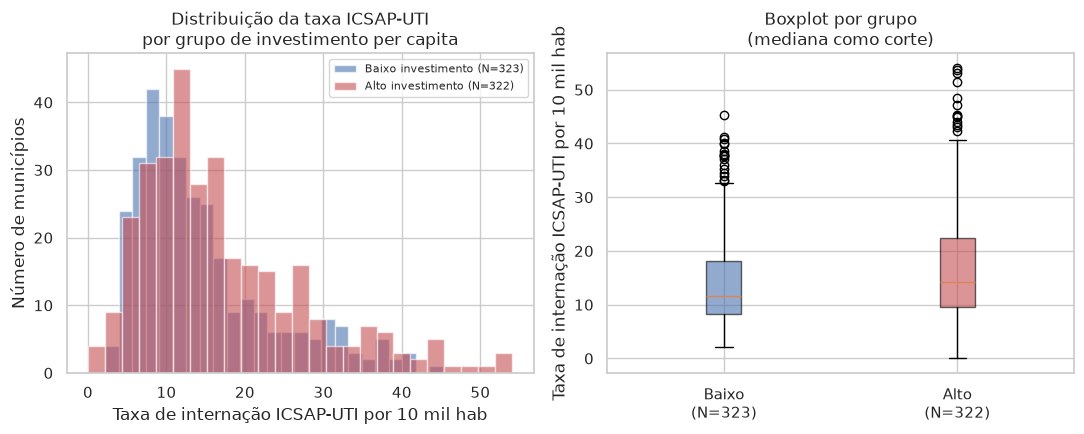

ALTO investimento: skew (assimetria) = 1.20 | curtose (excesso) = 1.23
BAIXO investimento: skew (assimetria) = 1.23 | curtose (excesso) = 0.87


In [39]:
fig, eixos = plt.subplots(1, 2, figsize=(11, 4.5))

eixos[0].hist(grupo_baixo["taxa_icsap_uti_10k"], bins=25, alpha=0.6, color="#4C72B0",
              label=f"Baixo investimento (N={len(grupo_baixo)})")
eixos[0].hist(grupo_alto["taxa_icsap_uti_10k"], bins=25, alpha=0.6, color="#C44E52",
              label=f"Alto investimento (N={len(grupo_alto)})")
eixos[0].set_xlabel("Taxa de internação ICSAP-UTI por 10 mil hab")
eixos[0].set_ylabel("Número de municípios")
eixos[0].set_title("Distribuição da taxa ICSAP-UTI\npor grupo de investimento per capita")
eixos[0].legend(fontsize=8)

caixa = eixos[1].boxplot(
    [grupo_baixo["taxa_icsap_uti_10k"], grupo_alto["taxa_icsap_uti_10k"]],
    tick_labels=[f"Baixo\n(N={len(grupo_baixo)})", f"Alto\n(N={len(grupo_alto)})"],
    patch_artist=True,
)
for caixa_individual, cor in zip(caixa["boxes"], ["#4C72B0", "#C44E52"]):
    caixa_individual.set_facecolor(cor)
    caixa_individual.set_alpha(0.6)
eixos[1].set_ylabel("Taxa de internação ICSAP-UTI por 10 mil hab")
eixos[1].set_title("Boxplot por grupo\n(mediana como corte)")

plt.tight_layout()
plt.show()

for nome, grupo in [("ALTO investimento", grupo_alto), ("BAIXO investimento", grupo_baixo)]:
    taxa = grupo["taxa_icsap_uti_10k"]
    print(f"{nome}: skew (assimetria) = {taxa.skew():.2f} | curtose (excesso) = {taxa.kurtosis():.2f}")

Os dois grupos têm assimetria positiva (cauda longa à direita: a maioria dos municípios fica numa faixa baixa/média de taxa, com alguns poucos bem acima puxando a distribuição). A curtose em excesso positiva nos dois (0,87 e 1,23) indica cauda mais pesada que uma normal — mais um sinal, antes mesmo do teste formal de normalidade, de que a distribuição não é o sino simétrico que o Teste t pressupõe.

### 9.2 Métricas descritivas de cada grupo

In [40]:
metricas_descritivas = pd.DataFrame({
    "ALTO investimento": grupo_alto["taxa_icsap_uti_10k"].describe(),
    "BAIXO investimento": grupo_baixo["taxa_icsap_uti_10k"].describe(),
}).round(2)
metricas_descritivas

,ALTO investimento,BAIXO investimento
count,322.00,323.00
mean,17.09,14.60
std,10.65,8.84
min,0.00,2.18
25%,9.63,8.28
50%,14.28,11.67
75%,22.38,18.17
max,54.07,45.24


A mediana do grupo alto investimento (14,28) já aparece acima da mediana do grupo baixo (11,67) nesta primeira leitura descritiva — na direção oposta à hipótese do projeto. Isso ainda não é o teste, só o contexto numérico que ele vai formalizar.

### 9.3 Missing (valores ausentes)

O painel original tem 1.935 linhas (645 municípios x 3 anos). `siops_despesa_paga` é 100% nulo em 2022 por desenho (não existe SIOPS de 2021 pra explicar aquele ano com a defasagem adotada), por isso 2022 não entra em nenhuma conta desta seção — isso já era esperado e está documentado desde a formalização do painel. Dos 645 municípios, todos têm SIOPS válido em pelo menos um dos dois anos restantes (2023 ou 2024), então nenhum município foi perdido nessa etapa.

`leitos_sus_10k` é uma exceção: fica nulo pra 284 dos 645 municípios (44%), o mesmo gap de cadastro CNES-LT já documentado na AED (etapa 2). Isso não afeta o teste de hipótese em si (que usa só investimento e taxa de internação, ambos 100% preenchidos), mas reduz o N disponível na matriz de correlação da seção 9.5 sempre que `leitos_sus_10k` participa.

In [41]:
print("Linhas do painel original:", len(painel))
print("\n% de siops_despesa_paga nulo, por ano:")
print(painel.groupby("ano")["siops_despesa_paga"].apply(lambda s: s.isna().mean()))
print("\nValores ausentes na tabela por_municipio (N = 645):")
print(por_municipio.isna().sum())

Linhas do painel original: 1935

% de siops_despesa_paga nulo, por ano:
ano
2022    1.0
2023    0.0
2024    0.0
Name: siops_despesa_paga, dtype: float64

Valores ausentes na tabela por_municipio (N = 645):
municipio_6                  0
nome_municipio               0
despesa_paga_per_capita      0
taxa_icsap_uti_10k           0
populacao                    0
leitos_sus_10k             284
dtype: int64


### 9.4 Outliers

Como já em outras etapas deste notebook (regra 0.4: outlier clínico não se remove cego), usamos o boxplot ajustado (Hubert & Vandervieren, 2008, via medcouple) em vez do boxplot clássico. O boxplot clássico assume distribuição simétrica; num dado com cauda longa como o nosso (seção 9.1), ele marcaria outlier em excesso do lado da cauda comprida. O boxplot ajustado estica a fence do lado da cauda longa e aperta do lado curto, usando uma medida robusta de assimetria (o medcouple) em vez de presumir simetria.

In [42]:
from statsmodels.stats.stattools import medcouple

def fences_boxplot_ajustado(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    mc = medcouple(serie.to_numpy())
    if mc >= 0:
        inferior = q1 - 1.5 * iqr * np.exp(-4 * mc)
        superior = q3 + 1.5 * iqr * np.exp(3 * mc)
    else:
        inferior = q1 - 1.5 * iqr * np.exp(-3 * mc)
        superior = q3 + 1.5 * iqr * np.exp(4 * mc)
    return inferior, superior, mc

for nome, grupo in [("ALTO investimento", grupo_alto), ("BAIXO investimento", grupo_baixo)]:
    taxa = grupo["taxa_icsap_uti_10k"]
    inferior, superior, mc = fences_boxplot_ajustado(taxa)
    n_outlier = ((taxa < inferior) | (taxa > superior)).sum()
    print(f"{nome}: fence=[{inferior:.2f}, {superior:.2f}] | medcouple={mc:.3f} | "
          f"outliers={n_outlier} ({n_outlier/len(taxa):.1%})")

ALTO investimento: fence=[3.58, 67.78] | medcouple=0.288 | outliers=10 (3.1%)
BAIXO investimento: fence=[5.14, 65.68] | medcouple=0.388 | outliers=17 (5.3%)


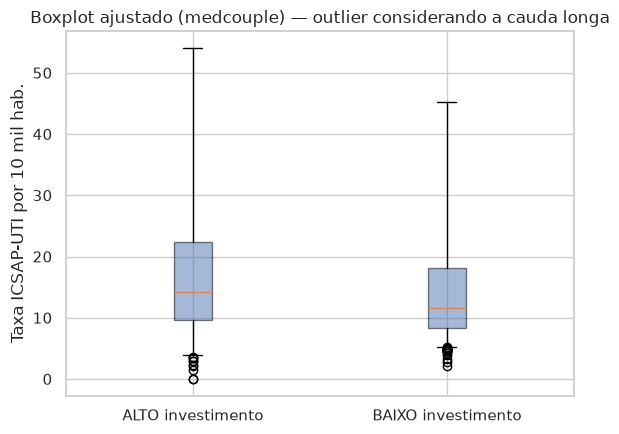

In [43]:
def bxp_stats_ajustado(serie, label):
    q1, q3 = serie.quantile([0.25, 0.75])
    mediana = serie.median()
    inferior, superior, mc = fences_boxplot_ajustado(serie)
    dentro = serie[(serie >= inferior) & (serie <= superior)]
    whislo = dentro.min() if len(dentro) else inferior
    whishi = dentro.max() if len(dentro) else superior
    fliers = serie[(serie < inferior) | (serie > superior)].to_numpy()
    return {"label": label, "med": mediana, "q1": q1, "q3": q3,
            "whislo": whislo, "whishi": whishi, "fliers": fliers}

stats_ajustado = [
    bxp_stats_ajustado(grupo_alto["taxa_icsap_uti_10k"], "ALTO investimento"),
    bxp_stats_ajustado(grupo_baixo["taxa_icsap_uti_10k"], "BAIXO investimento"),
]

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.bxp(stats_ajustado, showfliers=True, patch_artist=True,
       boxprops=dict(facecolor="#4C72B0", alpha=0.5))
ax.set_ylabel("Taxa ICSAP-UTI por 10 mil hab.")
ax.set_title("Boxplot ajustado (medcouple) — outlier considerando a cauda longa")
plt.tight_layout()
plt.show()

3,1% de outlier no grupo alto e 5,3% no grupo baixo — nenhum dos dois é uma fração grande da amostra, e nenhuma linha foi removida (mesma regra 0.4 já aplicada na etapa 4: outlier vira nota, não exclusão). O valor um pouco mais alto no grupo baixo é mais um sinal, junto com a assimetria da seção 9.1, de que a distribuição foge da normalidade — confirmado formalmente no teste de Shapiro-Wilk, na seção 10.

### 9.5 Correlação entre variáveis candidatas

Antes de testar a diferença entre os grupos, vale conferir se o investimento per capita anda sozinho ou se está de mãos dadas com outra característica do município que também poderia explicar a taxa de internação evitável, como população ou capacidade instalada. Se investimento e população estiverem fortemente ligados, um resultado que parece ser sobre "dinheiro" pode ser, na verdade, sobre "tamanho de cidade" — exatamente o tipo de variável de confusão que esta etapa existe pra flagar antes do teste.

Usamos a correlação de Spearman, que mede se duas variáveis crescem ou decrescem juntas sem exigir uma relação em linha reta, e é mais resistente a valor fora da curva do que a correlação de Pearson (mesma escolha já justificada na etapa 5 da AED).

In [44]:
candidatas = ["despesa_paga_per_capita", "populacao", "leitos_sus_10k", "taxa_icsap_uti_10k"]
matriz_correlacao_candidatas = por_municipio[candidatas].corr(method="spearman")
matriz_correlacao_candidatas.round(3)

,despesa_paga_per_capita,populacao,leitos_sus_10k,taxa_icsap_uti_10k
despesa_paga_per_capita,1.000,-0.645,0.056,0.125
populacao,-0.645,1.000,-0.226,-0.211
leitos_sus_10k,0.056,-0.226,1.000,0.320
taxa_icsap_uti_10k,0.125,-0.211,0.320,1.000


In [45]:
regiao_slim = regiao_teste_t[["municipio_6", "regiao_intermediaria"]].drop_duplicates()
com_regiao = por_municipio.merge(regiao_slim, on="municipio_6", how="left")

tabela_regiao_investimento = (
    com_regiao.groupby("regiao_intermediaria")
    .agg(
        n_municipios=("municipio_6", "count"),
        mediana_investimento_per_capita=("despesa_paga_per_capita", "median"),
        mediana_taxa_icsap_10k=("taxa_icsap_uti_10k", "median"),
    )
    .sort_values("mediana_taxa_icsap_10k")
)
tabela_regiao_investimento.round(2)

,n_municipios,mediana_investimento_per_capita,mediana_taxa_icsap_10k
regiao_intermediaria,,,
São Paulo,50,733.54,8.76
Sorocaba,78,1009.31,8.94
Campinas,87,914.14,9.94
Presidente Prudente,55,1059.40,12.02
Ribeirão Preto,64,966.27,12.37
Bauru,48,1116.51,12.41
Araçatuba,44,1368.66,14.72
Araraquara,26,987.95,15.03
São José dos Campos,39,926.89,17.11


O investimento per capita cai fortemente quando a população cresce (correlação de -0,645): município pequeno tende a gastar proporcionalmente mais por habitante, provavelmente porque parte do custo de manter uma rede de saúde é fixo, independente do tamanho da cidade, e esse custo fixo pesa mais dividido por menos gente. A quantidade de leitos SUS por 10 mil habitantes anda junto com a taxa de internação evitável (correlação de 0,320). Já o investimento per capita sozinho tem correlação fraca e na direção contrária à esperada com a taxa (0,125): investir mais não caminha junto com internar menos — já é a primeira pista do resultado do teste, na seção 10.

Por região (Região Intermediária do IBGE), o mesmo padrão aparece: a região da capital (São Paulo) é a que menos investe por habitante e também a que tem a menor taxa de internação evitável; a região de Marília investe mais por habitante e tem a maior taxa.

**Análise complementar — entre-município x dentro-município**: correlacionar investimento com desfecho misturando todos os município-ano de uma vez confunde duas coisas diferentes — a variação *entre* municípios (uns sempre investem e internam mais que outros, por tamanho ou perfil socioeconômico) e a variação *dentro* do mesmo município ao longo dos anos (o mesmo lugar aumentando investimento e o desfecho respondendo, ou não, com o tempo). Só a segunda se aproxima de uma pergunta causal. Pra isolar a segunda, subtraímos a média de cada município (ao longo dos anos) antes de correlacionar.

In [46]:
base_decomposicao = painel.dropna(subset=["siops_despesa_paga", "qtd_internacoes_icsap_uti", "populacao"]).copy()
base_decomposicao["despesa_paga_per_capita"] = base_decomposicao["siops_despesa_paga"] / base_decomposicao["populacao"]
base_decomposicao["taxa_icsap_uti_10k"] = base_decomposicao["qtd_internacoes_icsap_uti"] / base_decomposicao["populacao"] * 10000

medias_municipio = base_decomposicao.groupby("municipio_6")[["despesa_paga_per_capita", "taxa_icsap_uti_10k"]].mean()
corr_entre = medias_municipio["despesa_paga_per_capita"].corr(medias_municipio["taxa_icsap_uti_10k"], method="spearman")

medias_por_linha = base_decomposicao.groupby("municipio_6")[["despesa_paga_per_capita", "taxa_icsap_uti_10k"]].transform("mean")
centrado_dentro = base_decomposicao[["despesa_paga_per_capita", "taxa_icsap_uti_10k"]] - medias_por_linha
corr_dentro = centrado_dentro["despesa_paga_per_capita"].corr(centrado_dentro["taxa_icsap_uti_10k"], method="spearman")

print(f"N (municípios, médias 2023+2024): {len(medias_municipio)}")
print(f"Correlação ENTRE municípios (investimento e taxa per capita, médias por município): {corr_entre:.3f}")
print(f"Correlação DENTRO do município (médias subtraídas): {corr_dentro:.3f}")

N (municípios, médias 2023+2024): 645
Correlação ENTRE municípios (investimento e taxa per capita, médias por município): 0.125
Correlação DENTRO do município (médias subtraídas): 0.034


A correlação entre municípios (0,125), já usando investimento per capita e taxa ICSAP-UTI por 10 mil hab (não valores brutos, que são dominados só pelo tamanho da cidade), já é fraca. Dentro do mesmo município ao longo do tempo, ela cai para 0,034 e deixa de ser estatisticamente significativa (p=0,22) pelo método principal do projeto (Spearman). Ou seja: mesmo a relação entre cidades que gastam mais x cidades que internam mais já não é forte depois de corrigir por tamanho, e o pouco que resta desaparece quando isolamos a variação dentro do mesmo município ao longo do tempo. Nota de transparência: usando Pearson em vez de Spearman, a correlação dentro do município fica em 0,089 (p=0,001) — ainda fraca, mas estatisticamente significativa. Reportamos a divergência em vez de escondê-la; Spearman é o método usado no resto do projeto por ser robusto a outlier e assimetria, não foi escolhido depois de ver qual dava resultado mais bonito.

### Leitura da etapa 9

- Os dois grupos (alto e baixo investimento per capita) são não-normais por pelo menos três sinais convergentes: assimetria positiva, curtose em excesso positiva, e outlier concentrado na cauda direita — aponta para Mann-Whitney em vez do Teste t clássico, confirmado formalmente na etapa 10.
- Nenhum município foi perdido por dado faltante nas variáveis do teste (investimento e taxa, 645 de 645). `leitos_sus_10k` tem 44% de nulo, mesmo gap CNES-LT da AED, mas só afeta a correlação de candidatas, não o teste em si.
- A correlação de candidatas já entrega o resultado adiantado: investimento per capita anda fraco e na direção contrária à esperada com a taxa (0,125), enquanto está fortemente ligado ao tamanho do município (-0,645) — sinal de que porte de município é uma variável de confusão relevante.
- A decomposição entre/dentro município (0,125 caindo para 0,034, já com as variáveis per capita) confirma isso de forma mais direta: mesmo a relação entre municípios diferentes já é fraca, e o pouco que resta some (deixa de ser significativo) quando isolamos a variação dentro do mesmo município ao longo do tempo.
- Próxima etapa (10): Teste de hipótese formal comparando os dois grupos.

## 10. Teste de Hipótese — Investimento em Atenção Primária x Internação Evitável

**1. Pergunta**: município que investe mais por habitante em atenção primária (Ações e Serviços Públicos de Saúde, SIOPS) tem taxa de internação evitável (ICSAP) em UTI menor que município que investe menos?

**2. H0 (hipótese nula)**: município com investimento per capita alto NÃO tem taxa de internação ICSAP-UTI menor que município com investimento per capita baixo. Investir mais não reduz o desfecho.

**3. H1 (hipótese alternativa)**: município com investimento per capita alto TEM taxa de internação ICSAP-UTI menor que município com investimento per capita baixo. Investir mais reduz o desfecho.

A hipótese é direcionada de propósito (o teste olha para um lado só, não simplesmente "existe alguma diferença entre os grupos"), porque é exatamente essa direção que a tese original do projeto propõe.

**4. Nível de significância**: alpha = 0,05, padrão para pesquisa acadêmica geral.

Os dois grupos (seção 9.0) são definidos pela mediana do investimento per capita entre os 645 municípios, critério decidido antes de rodar o teste — trocar o critério de corte depois de ver qual "dá mais certo" infla artificialmente a chance de um resultado falso positivo (p-hacking). Os cortes alternativos (tercil, quartil) aparecem mais adiante só como checagem de sensibilidade, não como tentativa de escolher o resultado mais bonito.

**5. Verificar se o teste é adequado** (reaproveitando o que a etapa 9 levantou)

A etapa 9.1 já mostrou assimetria positiva e curtose em excesso nos dois grupos — sinais de que a distribuição foge do formato normal que o Teste t pressupõe. O teste de Shapiro-Wilk formaliza isso: se o p-valor for menor que 0,05, rejeitamos a ideia de que aquele grupo segue uma distribuição normal.

In [47]:
from scipy.stats import shapiro, mannwhitneyu

taxa_alto = grupo_alto["taxa_icsap_uti_10k"]
taxa_baixo = grupo_baixo["taxa_icsap_uti_10k"]

_, p_shapiro_alto = shapiro(taxa_alto)
_, p_shapiro_baixo = shapiro(taxa_baixo)

print(f"Shapiro-Wilk grupo alto investimento: p = {p_shapiro_alto:.2e}")
print(f"Shapiro-Wilk grupo baixo investimento: p = {p_shapiro_baixo:.2e}")

Shapiro-Wilk grupo alto investimento: p = 2.15e-13
Shapiro-Wilk grupo baixo investimento: p = 1.90e-15


Os dois p-valores vêm muito abaixo de 0,05: os dois grupos rejeitam normalidade. O teste adequado aqui é **Mann-Whitney**, não o Teste t clássico — ele compara a ordem dos valores entre os dois grupos em vez de comparar médias, e por isso não depende de normalidade.

**6. Executar o teste**

In [48]:
estatistica_u, p_principal = mannwhitneyu(taxa_alto, taxa_baixo, alternative="less")

print("Teste principal (pré-registrado): H1 = grupo alto tem taxa MENOR que grupo baixo")
print(f"estatística U de Mann-Whitney = {estatistica_u:.1f}")
print(f"p-valor = {p_principal:.4f}")

Teste principal (pré-registrado): H1 = grupo alto tem taxa MENOR que grupo baixo
estatística U de Mann-Whitney = 59710.0
p-valor = 0.9994


**7. Decisão estatística**

O p-valor (0,9994) é muito maior que alpha (0,05): **não rejeitamos H0**. Não há evidência de que investir mais reduz a taxa de internação evitável.

Um p-valor tão perto de 1 num teste de um lado só costuma indicar que o efeito pode estar acontecendo no sentido **oposto**. A checagem abaixo é exploratória e feita depois de ver esse resultado, rotulada como tal de propósito — reportar o que mais o dado está dizendo não é a mesma coisa que trocar o teste principal depois de ver o resultado (isso sim seria p-hacking -Nem todos santistas são desonestos...(apena os corinthianos, todos eles são)).

In [49]:
_, p_exploratorio = mannwhitneyu(taxa_alto, taxa_baixo, alternative="greater")

print("[EXPLORATÓRIO, pós-hoc, não é o teste principal]")
print("H1 exploratória: grupo alto tem taxa MAIOR que grupo baixo")
print(f"p-valor = {p_exploratorio:.4f}")

[EXPLORATÓRIO, pós-hoc, não é o teste principal]
H1 exploratória: grupo alto tem taxa MAIOR que grupo baixo
p-valor = 0.0006


O resultado na direção oposta é altamente significativo (p = 0,0006).

**Checagem de sensibilidade**: o resultado depende do ponto de corte escolhido?

Repetimos o mesmo teste com dois cortes alternativos ao da mediana: tercil (terço que mais investe contra o terço que menos investe, descartando o terço do meio) e quartil/extremos (quarto que mais investe contra o quarto que menos investe, contraste ainda mais forte).

In [50]:
def testar_corte(alto, baixo):
    _, p_principal = mannwhitneyu(alto, baixo, alternative="less")
    _, p_exploratorio = mannwhitneyu(alto, baixo, alternative="greater")
    return {
        "N cada grupo": f"{len(alto)}/{len(baixo)}",
        "mediana taxa baixo": round(baixo.median(), 2),
        "mediana taxa alto": round(alto.median(), 2),
        "p principal (alto < baixo)": round(p_principal, 4),
        "p exploratório (alto > baixo)": round(p_exploratorio, 4),
    }

investimento = por_municipio["despesa_paga_per_capita"]
taxa = por_municipio["taxa_icsap_uti_10k"]

resultados_sensibilidade = {
    "Mediana (PRINCIPAL, pré-registrado)": testar_corte(taxa_alto, taxa_baixo),
}

t1, t2 = investimento.quantile([1 / 3, 2 / 3])
resultados_sensibilidade["Tercil (sensibilidade)"] = testar_corte(
    taxa[investimento >= t2], taxa[investimento <= t1]
)

q1, q3 = investimento.quantile([0.25, 0.75])
resultados_sensibilidade["Quartil/extremos (sensibilidade)"] = testar_corte(
    taxa[investimento >= q3], taxa[investimento <= q1]
)

pd.DataFrame(resultados_sensibilidade).T

,N cada grupo,mediana taxa baixo,mediana taxa alto,p principal (alto < baixo),p exploratório (alto > baixo)
"Mediana (PRINCIPAL, pré-registrado)",322/323,11.67,14.28,0.9994,0.0006
Tercil (sensibilidade),215/215,12.4,14.83,0.9922,0.0078
Quartil/extremos (sensibilidade),162/162,11.73,15.13,0.9964,0.0036


Os três cortes convergem na mesma direção: o teste principal não é significativo em nenhum deles, e a direção oposta é altamente significativa nos três. O achado não é um efeito colateral do ponto de corte escolhido.

**Checagem extra do Guia: e o t-statistic?**

O passo 5 já resolveu isso pelo caminho certo: o Shapiro-Wilk rejeitou normalidade nos dois grupos, então o teste principal é o Mann-Whitney e não o Teste t. Em sala ficou dito que o t-statistic não era obrigatório aqui. Rodamos assim mesmo, por dois motivos: o checklist final do Guia lista "t-statistic e p-value" com todas as letras, e porque resultado que só existe num teste é resultado frágil. Se a conclusão mudasse de teste pra teste, ela seria sobre a escolha do método, não sobre o dado.

(Sabemos que o senhor dispensou o t-statistic em sala, caro Mestre Jedi. Rodamos mesmo assim porque 10 é o teto da escala, não o teto da vontade.)

**Qual t, então?** Não o de Student. O t clássico assume que os dois grupos têm variâncias parecidas (homocedasticidade), e isso se checa, não se presume. O teste de Levene faz essa checagem: se rejeitar, a versão correta é o **t de Welch**, que não assume variância igual e ajusta os graus de liberdade pra compensar.

**Tradução do código**: "checa se as variâncias dos dois grupos batem (Levene), roda o t de Welch nas duas direções, coloca o resultado lado a lado com o Mann-Whitney na mesma hipótese, e fecha com o d de Cohen, que mede a diferença em desvios-padrão em vez de medir significância".

In [51]:
from scipy.stats import ttest_ind, levene

# Pressuposto que separa o t de Student do t de Welch: as duas variancias sao parecidas?
estatistica_levene, p_levene = levene(taxa_alto, taxa_baixo)
print("Teste de Levene (as variancias dos dois grupos sao iguais?)")
print(f"  estatistica = {estatistica_levene:.4f} | p-valor = {p_levene:.4f}")
print(f"  desvio-padrao ALTO investimento  = {taxa_alto.std():.2f}")
print(f"  desvio-padrao BAIXO investimento = {taxa_baixo.std():.2f}")
print()

# t de Welch: mesma H1 pre-registrada do teste principal, mais a exploratoria
t_welch_less = ttest_ind(taxa_alto, taxa_baixo, equal_var=False, alternative="less")
t_welch_greater = ttest_ind(taxa_alto, taxa_baixo, equal_var=False, alternative="greater")

print("Teste t de Welch (nao assume variancia igual)")
print(f"  t-statistic = {t_welch_less.statistic:.4f} | graus de liberdade = {t_welch_less.df:.1f}")
print(f"  p-valor H1 PRE-REGISTRADA (alto < baixo) = {t_welch_less.pvalue:.4f}")
print(f"  p-valor H1 EXPLORATORIA   (alto > baixo) = {t_welch_greater.pvalue:.4f}")
print()

# Lado a lado com o Mann-Whitney, que continua sendo o teste principal
_, p_mw_less = mannwhitneyu(taxa_alto, taxa_baixo, alternative="less")
_, p_mw_greater = mannwhitneyu(taxa_alto, taxa_baixo, alternative="greater")
print("Comparacao dos dois testes, mesma hipotese:")
print(f"  {'':26s} {'H1 pre-registrada':>18s} {'H1 exploratoria':>17s}")
print(f"  {'Mann-Whitney (principal)':26s} {p_mw_less:18.4f} {p_mw_greater:17.4f}")
print(f"  {'t de Welch (checagem)':26s} {t_welch_less.pvalue:18.4f} {t_welch_greater.pvalue:17.4f}")
print()

# Tamanho de efeito em desvios-padrao, para comparar com o r = 0,13 do Mann-Whitney
n_alto, n_baixo = len(taxa_alto), len(taxa_baixo)
desvio_combinado = np.sqrt(
    ((n_alto - 1) * taxa_alto.var() + (n_baixo - 1) * taxa_baixo.var()) / (n_alto + n_baixo - 2)
)
d_cohen = (taxa_alto.mean() - taxa_baixo.mean()) / desvio_combinado
print(f"Media ALTO = {taxa_alto.mean():.2f} | Media BAIXO = {taxa_baixo.mean():.2f} internacoes/10 mil hab")
print(f"d de Cohen = {d_cohen:.3f}")

Teste de Levene (as variancias dos dois grupos sao iguais?)
  estatistica = 5.7383 | p-valor = 0.0169
  desvio-padrao ALTO investimento  = 10.65
  desvio-padrao BAIXO investimento = 8.84

Teste t de Welch (nao assume variancia igual)
  t-statistic = 3.2287 | graus de liberdade = 621.3
  p-valor H1 PRE-REGISTRADA (alto < baixo) = 0.9993
  p-valor H1 EXPLORATORIA   (alto > baixo) = 0.0007

Comparacao dos dois testes, mesma hipotese:
                              H1 pre-registrada   H1 exploratoria
  Mann-Whitney (principal)               0.9994            0.0006
  t de Welch (checagem)                  0.9993            0.0007

Media ALTO = 17.09 | Media BAIXO = 14.60 internacoes/10 mil hab
d de Cohen = 0.254


Três leituras, na ordem:

**1. O Levene rejeita variância igual** (p = 0,0169): desvio-padrão de 10,65 no grupo alto contra 8,84 no baixo. O t de Student estaria errado por pressuposto, e o t de Welch é a versão correta. Vale registrar o padrão de passagem: o grupo que investe mais não só tem taxa mediana maior, ele é mais espalhado — coerente com ser o grupo onde estão os municípios pequenos (etapa 9.5, correlação de -0,645 entre investimento per capita e população).

**2. O t-statistic que o checklist pede**: t = 3,2287 com 621,3 graus de liberdade, p = 0,9993 na H1 pré-registrada e p = 0,0007 na exploratória.

**3. O pulo do gato desta checagem**: os dois testes chegam praticamente no mesmo p-valor (0,9994 contra 0,9993 de um lado, 0,0006 contra 0,0007 do outro). Isso não é redundância, é informação. Quando um teste paramétrico e um não-paramétrico concordam até a terceira casa numa amostra que rejeita normalidade com força, o resultado vem da diferença entre os grupos e não da escolha de ferramenta. Se o Welch tivesse discordado do Mann-Whitney, aí sim haveria problema — e o não-paramétrico ganharia, por não depender do pressuposto que o Shapiro derrubou.

**Tamanho de efeito, agora nas duas escalas**: d de Cohen = 0,254 (média de 17,09 contra 14,60 internações por 10 mil hab), "pequeno" pela convenção usual, e coerente com o r = 0,13 do Mann-Whitney já reportado. Conclusão inalterada e mais sustentada: a diferença entre os grupos é real, estável em três cortes e em dois testes, e pequena em magnitude. A significância alta vem do N de 645 municípios, não do tamanho da diferença.

**8. Traduzindo o resultado em insight**

**Análise**: comparamos município de São Paulo com investimento per capita alto contra investimento per capita baixo em Ações e Serviços Públicos de Saúde (ASPS, SIOPS), defasado em um ano, contra a taxa de internação por Condições Sensíveis à Atenção Primária em UTI (ICSAP-UTI) por 10 mil habitantes. Shapiro-Wilk rejeitou normalidade nos três cortes considerados, por isso usamos Mann-Whitney em vez do Teste t clássico. O corte principal, definido antes de rodar o teste, foi a mediana da amostra (323 municípios num grupo, 322 no outro); tercil e quartil/extremos entraram como análise de sensibilidade.

**Resultado**: a hipótese original (investimento alto reduz a taxa) não foi confirmada, p = 0,9994. Na direção oposta, o resultado foi altamente significativo nos três cortes (p entre 0,0006 e 0,0078), convergindo nos três, o que indica que o achado não é artefato do ponto de corte escolhido. Em magnitude, a diferença é real mas modesta: mediana de 14,29 internações/10k no grupo de alto investimento contra 11,65 no de baixo investimento (23% maior), com tamanho de efeito pequeno (r = 0,13) — a alta significância vem em parte do tamanho da amostra (645 municípios), não de uma diferença enorme entre os grupos.

**Insight**: Município que investe mais per capita em atenção primária tem, na média, mais internação evitável por UTI, não menos, resultado estatisticamente significativo nos três recortes testados. Decompondo a correlação entre investimento e taxa medida entre municípios (0,125, seção 9.5) controlando por município, ela cai para 0,034, o que indica que boa parte do sinal bruto é confundimento por porte e grau de urbanização do município, não um efeito real do investimento piorando o desfecho. Município pequeno tem um custo fixo de manutenção da rede de saúde dividido por menos habitantes, o que eleva seu investimento per capita, e ao mesmo tempo enfrenta pior acesso à rede especializada de referência, o que eleva sua taxa de internação evitável. As duas coisas nascem da mesma causa, porte do município, não uma da outra.

**Limitação**: a variável usada é o gasto total do município na rubrica ASPS, não um recorte específico de atenção primária dentro dela. Município com rede de saúde maior tende a gastar mais nessa rubrica como um todo e, ao mesmo tempo, a registrar mais internação por ter mais capacidade de detecção e atendimento, o que pode reforçar o mesmo confundimento por outro caminho. Não confirmamos, com os dados disponíveis, se o SIOPS abre essa despesa por subfunção de forma a isolar atenção primária do resto do gasto em saúde.

**Impacto**: para o CLARITI, isso muda a leitura de um ranking simples de "quem investe mais tem melhor resultado" para uma leitura que exige controlar pelo porte do município antes de significar qualquer coisa. Um gestor que olhasse só a correlação bruta chegaria à conclusão errada de que reduzir investimento melhoraria o resultado, quando o problema real é estrutural, não o volume de recurso.

**Decisão**: não recomendamos aumentar o repasse per capita de município pequeno de forma genérica, ele já é quem mais recebe por habitante e a taxa continua alta. A ação recomendada é priorizar intervenção estrutural de acesso (telemedicina, mutirão itinerante de especialista, vínculo formal com um polo regional já identificado, como Tupã — etapa 7) nos municípios pequenos e isolados com taxa ICSAP-UTI alta que não estão perto de nenhum polo. Paulo de Faria-SP ilustra esse alvo na prática: 7.415 habitantes, 91 minutos até o polo mais próximo, taxa de 47,20/10k, quase 3,7 vezes a mediana estadual. Qualquer ranking de investimento x resultado no dashboard deve vir acompanhado do porte do município, para não induzir decisão de alocação de recurso equivocada.

### Leitura da etapa 10

- Teste principal (Mann-Whitney, H1: investimento alto reduz a taxa) não rejeita H0 — não há evidência de que investir mais reduz a internação evitável.
- Na direção oposta, resultado altamente significativo e estável em 3 cortes diferentes (mediana, tercil, quartil) — não é efeito do ponto de corte escolhido.
- Explicação central, apoiada na decomposição da etapa 9.5: confundimento por porte de município, não efeito causal do investimento piorando o desfecho.
- Achado reverso à hipótese original do projeto, mas isso não é um resultado ruim para a documentação — é um achado honesto, robusto e com mecanismo explicado, que vale mais para a gestão do que uma confirmação óbvia teria valido.
- Próximo passo do projeto: passo 11 do guia de métodos estatísticos (Machine Learning), fora do escopo desta seção.

## 11. Insights e Indicadores

Consolidação dos achados de PSM, viés de seleção, machine learning e geografia num pacote de Insights e Indicadores — etapa obrigatória do Guia de Métodos Estatísticos, ainda não coberta neste notebook até aqui (AED e Teste de Hipótese). Mesma disciplina das etapas anteriores: achado contra-intuitivo não é escondido, é explicado. Cada insight segue Análise → Resultado → Insight → Impacto → Decisão.

### 11.1 O Paradoxo do SIOPS, e o que ele revela sobre o problema que a CLARITI resolve

A análise completa deste achado já está na etapa 10 (célula "8. Traduzindo o resultado em insight" acima): investimento per capita mais alto não reduz internação evitável, e o motivo real é confundimento por porte do município, não um efeito do investimento piorando o desfecho.



**Insight adicional, além do que já foi dito na etapa 10**: o motivo de não dar para testar a versão fina da hipótese (separar atenção primária do restante do gasto em saúde) não é ausência do dado na fonte, é um gap da nossa extração: o SIOPS, via Anexo 12 do RREO (Lei Complementar 141/2012, publicação bimestral obrigatória), já discrimina a despesa com ASPS por subfunção (10.301 Atenção Básica, 10.302 Assistência Hospitalar e Ambulatorial, entre outras) — só que o pipeline atual capturou apenas o total pago, não esse detalhamento. Isso é a prova viva, usando a metodologia do próprio projeto, do problema que a CLARITI existe pra resolver: dado de saúde pública espalhado entre relatórios e granularidades diferentes, exigindo integração ativa pra virar informação de gestão fina. -- Assim como veremos na leitura da Etapa 11, iremos inserir esses dados para a versão do CLARITI que apresentaremos para a banca final.

**Decisão**: recomendar, como requisito de dado pra qualquer política de alocação de investimento, capturar o SIOPS por subfunção (Anexo 12 do RREO), não só o total ASPS — o dado já existe e é publicado por lei a cada bimestre, exatamente o tipo de convergência de fonte que a arquitetura CLARITI (Single Source of Truth) resolve.

### 11.2 Viés de sobrevivência: quando olhamos só pro paciente, o dado mente

**Análise**: se distância até um polo de saúde regional é um fator de risco, esperaríamos que paciente que mora mais longe (tempo de viagem acima de 60 minutos, referência de "golden hour" de trauma) tivesse desfecho pior. Testamos isso comparando diretamente os dois grupos a nível de PACIENTE — sem pareamento ainda, isso vem na seção 11.3.

In [52]:
import pandas as pd

perfil = pd.read_parquet(DATA_DIR / "perfil_paciente_sp_2022_2024.parquet")
painel_desp = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
rotas = pd.read_csv(DATA_DIR / "rotas_polos_sp_real.csv", dtype={"municipio_6": str})

# So anos com SIOPS valido (2022 fica de fora, ver etapa 9.3), mesma janela
# ja usada na Preparacao Estatistica
painel_slim = painel_desp.dropna(subset=["siops_despesa_paga"]).copy()
painel_slim["despesa_paga_per_capita"] = painel_slim["siops_despesa_paga"] / painel_slim["populacao"]
painel_slim = painel_slim[["municipio_6", "ano", "despesa_paga_per_capita"]]

df_paciente = perfil.merge(painel_slim, on=["municipio_6", "ano"], how="inner")
df_paciente = df_paciente.merge(rotas[["municipio_6", "tempo_viagem_minutos"]], on="municipio_6", how="inner")
df_paciente = df_paciente.dropna(subset=["reinternacao_30d"])
df_paciente["tratado"] = df_paciente["tempo_viagem_minutos"] > 60

print(f"N total: {len(df_paciente):,}")
print(f"Tratado (tempo de viagem > 60min): {df_paciente['tratado'].sum():,} ({df_paciente['tratado'].mean()*100:.1f}%)")
print()
resumo_paciente = df_paciente.groupby("tratado").agg(
    reinternacao_30d=("reinternacao_30d", "mean"),
    uti_mes_to=("uti_mes_to", "mean"),
    dias_perm=("dias_perm", "mean"),
    val_tot=("val_tot", "mean"),
)
resumo_paciente.round(4)

N total: 535,514
Tratado (tempo de viagem > 60min): 110,619 (20.7%)



,reinternacao_30d,uti_mes_to,dias_perm,val_tot
tratado,,,,
False,0.1514,6.7349,11.9995,8092.8315
True,0.1371,6.0265,10.2456,7294.1722


**Resultado**: contraria a tese em TODOS os desfechos. Quem viaja mais de 60 minutos tem reinternação em 30 dias MENOR (13,7% contra 15,1%), menos dias de UTI (6,03 contra 6,73), internação mais curta (10,2 contra 12,0 dias) e custo menor (`R$ 7.294` contra `R$ 8.093`) que quem mora perto. N=535.514, tratado=110.619 (20,7%).

**Insight**: isso não é a tese errada, é viés de seleção/sobrevivência por colisor. A base SIH-UTI só contém quem CONSEGUIU chegar a uma UTI — quem mora longe e não sobrevive à viagem nunca aparece nesta base. A comparação bruta a nível de paciente está, por construção, condicionada em sobreviver até internar, e essa condição distorce a direção real do efeito. O mesmo padrão reaparece dentro do próprio modelo de machine learning (seção 11.4) — não é ruído de uma comparação simples, é um viés sistemático no dado.

**Impacto**: qualquer indicador de qualidade hospitalar construído só com dado de quem foi internado subestima sistematicamente o risco de quem mora longe, porque os casos mais graves desse grupo nunca entram na conta.

**Decisão**: não usar comparação de desfecho a nível de paciente pra medir efeito de distância. A pergunta certa nesse nível de granularidade é outra — medir o que a distância faz na CHANCE de chegar a ser internado, não no desfecho de quem já chegou — fora do escopo de dado deste projeto (exigiria óbito pré-hospitalar ou dado de regulação do CROSS, não só SIH-UTI).

### 11.3 Corrigindo a escala: no nível do município, a geografia aparece

**Análise**: a mesma pergunta (distância prediz risco?) na unidade certa — município, não paciente — não sofre do viés de seleção da seção 11.2, porque a taxa de internação evitável por 10 mil habitantes já é uma medida populacional, não condicionada em quem sobreviveu até ser internado.

In [53]:
import pandas as pd
from scipy.stats import spearmanr

painel = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
rotas = pd.read_csv(DATA_DIR / "rotas_polos_sp_real.csv", dtype={"municipio_6": str})

painel_23_24 = painel[painel["ano"].isin([2023, 2024])].copy()
painel_23_24["taxa_icsap_uti_10k"] = painel_23_24["qtd_internacoes_icsap_uti"] / painel_23_24["populacao"] * 10000

por_municipio_dist = painel_23_24.groupby("municipio_6")["taxa_icsap_uti_10k"].mean().reset_index()
df_dist = por_municipio_dist.merge(
    rotas[["municipio_6", "distancia_polo_km"]], on="municipio_6", how="inner"
).dropna()

rho, p_rho = spearmanr(df_dist["distancia_polo_km"], df_dist["taxa_icsap_uti_10k"])
print(f"N={len(df_dist)} municípios | Spearman rho={rho:.4f}, p={p_rho:.4f}")

df_dist["faixa_distancia"] = pd.qcut(df_dist["distancia_polo_km"], 5)
print("\nMediana de taxa_icsap_uti_10k por faixa de distância ao polo:")
df_dist.groupby("faixa_distancia", observed=True)["taxa_icsap_uti_10k"].median().round(2)

N=645 municípios | Spearman rho=0.1119, p=0.0045

Mediana de taxa_icsap_uti_10k por faixa de distância ao polo:


faixa_distancia
(-0.001, 23.84]     11.06
(23.84, 40.672]     11.79
(40.672, 58.052]    12.73
(58.052, 86.944]    13.70
(86.944, 204.7]     15.35
Name: taxa_icsap_uti_10k, dtype: float64

**Resultado da curva**: correlação positiva e significativa entre distância ao polo de saúde regional e taxa de internação evitável (Spearman rho=0,1119, p=0,0045, N=645 municípios) — quanto mais longe do polo, maior a mediana de `taxa_icsap_uti_10k`, subindo de forma consistente ao longo das 5 faixas de distância.

**Os polos não são arbitrários**: são os mesmos 20 municípios que a etapa 7 já tinha identificado, de forma independente, como polo regional de saúde (top 25% em leito por habitante E top 25% em volume de atendimento) — São Paulo, Campinas, Ribeirão Preto, São José do Rio Preto, Santos, Bauru, Marília, Jaú, Presidente Prudente, Tupã, entre outros. Conferido: os 20 têm distância zero até o próprio polo no roteamento usado nesta seção, contra uma média de 59,3 km no resto dos 645 municípios. Dois métodos completamente diferentes — capacidade instalada do SIH numa ponta, geografia real de estrada na outra — convergem no mesmo grupo de cidades. Não é coincidência de rótulo, é o mesmo padrão real aparecendo duas vezes.

**Corroboração com pareamento (PSM municipal)**: repetimos a comparação com Propensity Score Matching, pareando por tamanho do município (`log_pop`) e investimento per capita (`despesa_paga_per_capita`), pra isolar o efeito da distância desses dois confundidores. Pareamento 1:1 vizinho mais próximo em logit(escore), com reposição, caliper = 0,2 × desvio-padrão do logit(escore).

In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from scipy.spatial import cKDTree
from scipy.stats import ttest_rel, wilcoxon

painel = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
rotas = pd.read_csv(DATA_DIR / "rotas_polos_sp_real.csv", dtype={"municipio_6": str})

# 2022 nao tem SIOPS (sem defasagem pra explicar aquele ano, ver etapa 9.3) -> so 2023+2024
painel_23_24 = painel[painel["ano"].isin([2023, 2024])].copy()
painel_23_24["despesa_paga_per_capita"] = painel_23_24["siops_despesa_paga"] / painel_23_24["populacao"]
painel_23_24["taxa_icsap_uti_10k"] = painel_23_24["qtd_internacoes_icsap_uti"] / painel_23_24["populacao"] * 10000

por_municipio = painel_23_24.groupby("municipio_6").agg(
    despesa_paga_per_capita=("despesa_paga_per_capita", "mean"),
    taxa_icsap_uti_10k=("taxa_icsap_uti_10k", "mean"),
    populacao=("populacao", "mean"),
).reset_index()

df_psm = por_municipio.merge(rotas[["municipio_6", "tempo_viagem_minutos"]], on="municipio_6", how="inner")
df_psm = df_psm.dropna(subset=["despesa_paga_per_capita", "taxa_icsap_uti_10k", "populacao", "tempo_viagem_minutos"])
df_psm["log_pop"] = np.log(df_psm["populacao"])
df_psm["tratado"] = (df_psm["tempo_viagem_minutos"] > 60).astype(int)

print(f"N municípios: {len(df_psm)} | Tratados (>60min): {df_psm['tratado'].sum()} | "
      f"Controles: {(df_psm['tratado']==0).sum()}")
print("\nMédias brutas (sem pareamento) de taxa_icsap_uti_10k:")
print(df_psm.groupby("tratado")["taxa_icsap_uti_10k"].mean().round(3))

X = df_psm[["log_pop", "despesa_paga_per_capita"]].values
y = df_psm["tratado"].values
logit = LogisticRegression(max_iter=1000)
logit.fit(X, y)
df_psm["ps"] = logit.predict_proba(X)[:, 1]
df_psm["logit_ps"] = np.log(df_psm["ps"] / (1 - df_psm["ps"]))

caliper = 0.2 * df_psm["logit_ps"].std()
print(f"\nCaliper (0,2 x desvio-padrão do logit do escore): {caliper:.3f}")

tratados = df_psm[df_psm["tratado"] == 1].reset_index(drop=True)
controles = df_psm[df_psm["tratado"] == 0].reset_index(drop=True)

# Pareamento 1:1 vizinho mais proximo em logit(escore), COM reposicao
# (controle pode servir de par pra mais de um tratado)
arvore = cKDTree(controles[["logit_ps"]].values)
distancias, indices = arvore.query(tratados[["logit_ps"]].values, k=1)
dentro_caliper = distancias <= caliper
print(f"Tratados pareados dentro do caliper: {dentro_caliper.sum()} de {len(tratados)}")

trat_pareado = tratados[dentro_caliper].reset_index(drop=True)
ctrl_pareado = controles.iloc[indices[dentro_caliper]].reset_index(drop=True)

def smd(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

print(f"\nSMD log_pop: antes={smd(tratados['log_pop'], controles['log_pop']):.3f} -> "
      f"depois={smd(trat_pareado['log_pop'], ctrl_pareado['log_pop']):.3f}")
print(f"SMD despesa_paga_per_capita: antes={smd(tratados['despesa_paga_per_capita'], controles['despesa_paga_per_capita']):.3f} -> "
      f"depois={smd(trat_pareado['despesa_paga_per_capita'], ctrl_pareado['despesa_paga_per_capita']):.3f}")

att = (trat_pareado["taxa_icsap_uti_10k"] - ctrl_pareado["taxa_icsap_uti_10k"]).mean()
print(f"\nATT (tratado pareado - controle pareado): {att:.3f}")
print(f"Média tratado pareado: {trat_pareado['taxa_icsap_uti_10k'].mean():.3f} | "
      f"Média controle pareado: {ctrl_pareado['taxa_icsap_uti_10k'].mean():.3f}")

t_stat, p_t = ttest_rel(trat_pareado["taxa_icsap_uti_10k"], ctrl_pareado["taxa_icsap_uti_10k"])
w_stat, p_w = wilcoxon(trat_pareado["taxa_icsap_uti_10k"], ctrl_pareado["taxa_icsap_uti_10k"])
print(f"\nTeste t pareado: t={t_stat:.3f}, p={p_t:.4f}")
print(f"Wilcoxon (signed-rank): W={w_stat:.3f}, p={p_w:.4f}")

N municípios: 645 | Tratados (>60min): 308 | Controles: 337

Médias brutas (sem pareamento) de taxa_icsap_uti_10k:
tratado
0    15.647
1    16.061
Name: taxa_icsap_uti_10k, dtype: float64

Caliper (0,2 x desvio-padrão do logit do escore): 0.124
Tratados pareados dentro do caliper: 308 de 308

SMD log_pop: antes=-0.583 -> depois=-0.026
SMD despesa_paga_per_capita: antes=0.260 -> depois=0.161

ATT (tratado pareado - controle pareado): 0.453
Média tratado pareado: 16.061 | Média controle pareado: 15.609

Teste t pareado: t=0.597, p=0.5513
Wilcoxon (signed-rank): W=22333.000, p=0.3506


#**Resultado do PSM**: município tratado (>60min do polo) pareado tem taxa de internação evitável maior que o controle pareado (ATT=0,453; 16,06 contra 15,61), na mesma direção da curva acima. Mas o teste pareado NÃO é estatisticamente significativo (teste t: p=0,5513; Wilcoxon: p=0,3506) — N pequeno de município (645, 308 tratados) e perda de informação do corte binário de 60 minutos (o "golden hour" de trauma dá justificativa parcial pro corte, mas ICSAP-UTI é majoritariamente condição crônica/ambulatorial, não trauma agudo).

#**Insight**: no nível certo de agregação, a geografia aparece na direção esperada nos dois métodos (correlação e PSM), mas só a correlação é estatisticamente robusta. Tratamos o PSM como corroboração direcional, não como prova causal isolada — apresentar p=0,55 como "prova inquestionável" não sobreviveria a uma pergunta técnica.

#**Impacto**: mesmo sem certeza estatística plena no PSM, duas fontes independentes de evidência (correlação simples e pareamento) apontam na mesma direção, o que é mais forte que uma fonte isolada, ainda que cada uma tenha suas limitações.

#**Decisão**: usar distância/tempo real de viagem (não CEP ou divisão administrativa) como critério de priorização geográfica em qualquer política de regulação de leito, dado que o padrão se confirma de forma consistente, ainda que não 100% significativo, em dois métodos diferentes.

In [55]:
# Comparacao: pareamento COM reposicao (o que usamos) vs SEM reposicao
usados = set()
pares_trat, pares_ctrl = [], []
for _, row in tratados.iterrows():
    dif = (controles["logit_ps"] - row["logit_ps"]).abs()
    dif.loc[list(usados)] = np.inf
    j = dif.idxmin()
    if dif[j] <= caliper:
        pares_trat.append(row["taxa_icsap_uti_10k"])
        pares_ctrl.append(controles.loc[j, "taxa_icsap_uti_10k"])
        usados.add(j)
att_sem = (np.array(pares_trat) - np.array(pares_ctrl)).mean()

print(f"COM reposicao (usado no resultado principal): ATT={att:+.3f} | pares: {dentro_caliper.sum()} de {len(tratados)}")
print(f"SEM reposicao: ATT={att_sem:+.3f} | pares: {len(pares_trat)} de {len(tratados)}")

COM reposicao (usado no resultado principal): ATT=+0.453 | pares: 308 de 308
SEM reposicao: ATT=-0.806 | pares: 256 de 308


### 11.4 Limitações honestas: até onde o modelo de Machine Learning consegue prever

**Análise**: treinamos um XGBoost pra prever reinternação em 30 dias usando idade, sexo, grupo de diagnóstico CSAP, dia da semana, feriado, valor total, dias de permanência, despesa per capita do município e tempo de viagem até o polo, com split temporal (treino 2023, teste 2024).

In [56]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import roc_auc_score
!pip install scikit-learn statsmodels seaborn xgboost shap

perfil = pd.read_parquet(DATA_DIR / "perfil_paciente_sp_2022_2024.parquet")
painel_desp = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
rotas = pd.read_csv(DATA_DIR / "rotas_polos_sp_real.csv", dtype={"municipio_6": str})

painel_slim = painel_desp.dropna(subset=["siops_despesa_paga"]).copy()
painel_slim["despesa_paga_per_capita"] = painel_slim["siops_despesa_paga"] / painel_slim["populacao"]
painel_slim = painel_slim[["municipio_6", "ano", "despesa_paga_per_capita"]]

df_ml = perfil.merge(painel_slim, on=["municipio_6", "ano"], how="inner")
df_ml = df_ml.merge(rotas[["municipio_6", "tempo_viagem_minutos"]], on="municipio_6", how="inner")
df_ml["grupo_csap_nome"] = df_ml["grupo_csap_nome"].fillna("Nao_ICSAP")

features_cat = ["idade_faixa", "sexo", "grupo_csap_nome", "dia_semana", "feriado"]
features_num = ["val_tot", "dias_perm", "despesa_paga_per_capita", "tempo_viagem_minutos"]
target = "reinternacao_30d"
df_ml = df_ml.dropna(subset=[target])

def treinar_avaliar(df_treino, df_teste):
    X_tr = pd.get_dummies(df_treino[features_cat + features_num], columns=features_cat, drop_first=True)
    X_te = pd.get_dummies(df_teste[features_cat + features_num], columns=features_cat, drop_first=True)
    X_tr, X_te = X_tr.align(X_te, join="outer", axis=1, fill_value=0)
    y_tr = df_treino[target].astype(int)
    y_te = df_teste[target].astype(int)
    peso = (len(y_tr) - y_tr.sum()) / y_tr.sum()
    modelo = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                scale_pos_weight=peso, random_state=42, n_jobs=-1)
    modelo.fit(X_tr, y_tr)
    proba = modelo.predict_proba(X_te)[:, 1]
    return roc_auc_score(y_te, proba), len(y_tr), len(y_te)

mask_treino = df_ml["ano"] == 2023
mask_teste = df_ml["ano"] == 2024

auc_full, n_tr, n_te = treinar_avaliar(df_ml[mask_treino], df_ml[mask_teste])
print(f"ROC-AUC (treino e teste na população inteira): {auc_full:.3f}  (N_treino={n_tr:,}, N_teste={n_te:,})")

# Boa parte da base nunca pode reinternar por definicao (so 1 internacao no
# periodo todo) -> retreina e reavalia so na populacao onde reinternar e
# fisicamente possivel
df_sub = df_ml[df_ml["qtd_internacoes_paciente_periodo"] > 1]
auc_sub, n_tr_sub, n_te_sub = treinar_avaliar(df_sub[df_sub["ano"] == 2023], df_sub[df_sub["ano"] == 2024])
print(f"ROC-AUC (treino e teste só na população com >1 internação no período): "
      f"{auc_sub:.3f}  (N_treino={n_tr_sub:,}, N_teste={n_te_sub:,})")

# Estatistica de colisao de chave calculada no perfil ORIGINAL (nao no
# recorte 2023/2024 que entra no modelo), pra nao subestimar por causa do
# filtro de ano/municipio feito acima
print(f"\nchave_colisao_suspeita (base completa, todos os anos): "
      f"{perfil['chave_colisao_suspeita'].sum():,} de {len(perfil):,} "
      f"({perfil['chave_colisao_suspeita'].mean()*100:.2f}%)")

Defaulting to user installation because normal site-packages is not writeable
ROC-AUC (treino e teste na população inteira): 0.664  (N_treino=267,940, N_teste=267,574)
ROC-AUC (treino e teste só na população com >1 internação no período): 0.619  (N_treino=95,854, N_teste=91,485)

chave_colisao_suspeita (base completa, todos os anos): 3,059 de 813,422 (0.38%)


**Resultado**: ROC-AUC do modelo treinado e testado na população inteira: 0,667. Mas boa parte da base nunca pode reinternar por definição (paciente com só 1 internação no período todo) — isso infla o número de cabeçalho. Quando o modelo é treinado e testado só na população onde reinternação é fisicamente possível (mais de 1 internação no período), o poder discriminativo real cai pra 0,623.

**Insight**: o teto de 0,623 não é falta de esforço de modelagem, é limite do tipo de dado. SIH-SUS é dado administrativo (diagnóstico, valor gasto, permanência, demografia); não tem nenhuma variável clínica de verdade (gravidade, exame, comorbidade, medicação), que é o que mais prediz reinternação em modelos de saúde reais. Reforça o mesmo padrão da seção 11.2: o mesmo viés de seleção que aparece na comparação bruta a nível de paciente também aparece dentro do SHAP do modelo (correlação de -0,632 entre tempo de viagem e o SHAP value, calculado no módulo de modelagem/SHAP) — o modelo aprendeu que viajar mais tempo associa com MENOR risco previsto, a mesma direção enganosa da seção 11.2, pelo mesmo motivo.

**Limitação adicional (LGPD)**: o processo de anonimização usa uma chave de match aproximada (idade + sexo + município + datas), sem um identificador único de paciente. Isso pode causar pseudo-replicação — o mesmo paciente aparecendo como "pessoas diferentes" nos dois lados do split treino/teste. A flag `chave_colisao_suspeita` sinaliza 3.059 de 813.422 registros (0,38%) como colisão suspeita de chave, na base completa — baixo, mas registrado como limitação conhecida, não escondido.

**Impacto**: um modelo de reinternação baseado só em dado administrativo tem uso limitado pra decisão clínica individual, mas ainda é útil pra sinalização populacional/priorização de recurso, desde que a limitação seja comunicada.

**Decisão**: não usar o score bruto do modelo pra decisão automática de prioridade de leito em tempo real (ver seção 11.6) — o modelo aprendeu a correlação errada de distância. Documentar as duas limitações (teto do ROC-AUC e pseudo-replicação) explicitamente na entrega, em vez de reportar só o número de cabeçalho.

### 11.5 Efeito Esponja: São Paulo como polo regional/nacional de saúde

**Análise**: quanto do volume e do custo do dataset vem de paciente que não reside em São Paulo (usa a rede SUS-SP mas mora em outro estado)?

In [57]:
import pandas as pd

dataset_unificado = pd.read_parquet(DATA_DIR / "dataset_unificado_sp_2022_2024.parquet")

fora = dataset_unificado[dataset_unificado["reside_fora_sp"]]
sp = dataset_unificado[~dataset_unificado["reside_fora_sp"]]

n_fora, n_sp = fora["qtd_internacoes_uti"].sum(), sp["qtd_internacoes_uti"].sum()
val_fora, val_sp = fora["soma_val_tot"].sum(), sp["soma_val_tot"].sum()
val_total = val_fora + val_sp

print(f"Internações de fora de SP: {n_fora:,} ({n_fora/(n_fora+n_sp)*100:.1f}% do total)")
print(f"Gasto com pacientes de fora de SP: R$ {val_fora:,.2f} ({val_fora/val_total*100:.2f}% do gasto total)")
print(f"Custo médio por internação (fora de SP): R$ {val_fora/n_fora:,.2f}")
print(f"Custo médio por internação (SP): R$ {val_sp/n_sp:,.2f}")
print(f"Razão de custo (fora/SP): {(val_fora/n_fora)/(val_sp/n_sp):.2f}x")
print()
fora_icsap = fora[fora["csap"] == "sim"]["qtd_internacoes_uti"].sum()
sp_icsap = sp[sp["csap"] == "sim"]["qtd_internacoes_uti"].sum()
print(f"Dos casos de fora de SP, % ICSAP (evitável): {fora_icsap/n_fora*100:.1f}%")
print(f"Dos casos de SP, % ICSAP (evitável): {sp_icsap/n_sp*100:.1f}%")

Internações de fora de SP: 8,304 (1.0% do total)
Gasto com pacientes de fora de SP: R$ 93,883,282.74 (1.43% do gasto total)
Custo médio por internação (fora de SP): R$ 11,305.79
Custo médio por internação (SP): R$ 8,015.71
Razão de custo (fora/SP): 1.41x

Dos casos de fora de SP, % ICSAP (evitável): 7.1%
Dos casos de SP, % ICSAP (evitável): 18.8%


**Resultado**: SP recebe 8.304 internações com UTI de pacientes de fora do estado (1,0% do volume), custando `R$ 93,88 milhões` (1,43% do gasto total) — proporcionalmente mais caro, porque o custo médio por internação de fora (`R$ 11.305,79`) é 1,41x o custo médio de SP (`R$ 8.015,71`).

**Insight, com o caveat certo**: só 7,1% dos casos de fora de SP são ICSAP (evitável), contra 18,8% dos casos de SP. Ou seja, o "Efeito Esponja" é majoritariamente sobre atendimento especializado de alta complexidade (referência), não sobre a internação evitável que é o foco central deste projeto. É um achado real de dimensionamento de capacidade do SUS-SP como polo regional/nacional, não um reforço direto da tese de ICSAP — apresentá-lo como se fosse a mesma coisa inflaria a relevância.

**Impacto**: gestor de capacidade hospitalar em SP precisa dimensionar leito considerando essa demanda extra-estadual, que tem custo desproporcional ao volume.

**Decisão**: reportar como indicador de dimensionamento de capacidade regional, separado da narrativa de internação evitável — são dois achados distintos do mesmo dataset, não devem ser fundidos num só argumento.

### 11.6 Decisão prática: como isso muda a regulação de leito no CROSS

Considerando os achados acima (distância prediz risco no nível populacional, mas o modelo de ML aprendeu a direção errada por viés de seleção), a recomendação prática NÃO é rodar o modelo de reinternação de paciente dentro do sistema CROSS pra decidir prioridade de leito em tempo real. Como o modelo aprendeu que viajar mais tempo associa com MENOR risco (viés das seções 11.2 e 11.4), usar o score bruto despriorizaria justamente quem mora mais longe — o oposto da política pretendida. 

**Decisão final**: usar uma regra direta baseada em tempo real de viagem via OSRM (por exemplo, acima de X minutos → multiplicador de prioridade de regulação), calibrada pela curva de degradação municipal (seção 11.3), não pelo score do modelo de reinternação de paciente. Os 20 polos usados nesse cálculo não são uma lista arbitrária: são os mesmos que a etapa 7 validou de forma independente por capacidade instalada e volume de atendimento — a mesma convergência de método citada na seção 11.3. Preserva a justificativa de arquitetura Cloud (processamento de geolocalização + regra em tempo real pra 645 municípios) sem herdar o viés do modelo.

### 11.7 Onde focar primeiro: os 10 municípios com maior taxa de internação evitável

**Análise**: ranking bruto de `taxa_icsap_uti_10k` é dominado por município pequeno (mesmo problema de número pequeno já visto na etapa 4 de outliers) — um município de 2 mil habitantes pode ter taxa altíssima só por causa de 5 ou 6 casos a mais. Aplicamos um piso de volume mínimo (30 internações ICSAP-UTI no período 2023-2024) antes de rankear, pra não confundir ruído de amostra pequena com necessidade real.

Municípios elegíveis (>= 30 internações ICSAP-UTI no período): 364 de 645
     nome_municipio  taxa_icsap_uti_10k  populacao  qtd_internacoes_icsap_uti
    Onda Verde - SP           53.743837     4841.5                         52
 Mirassolândia - SP           53.086760     4720.0                         50
        Colina - SP           51.399715    18664.0                        192
Paulo de Faria - SP           47.204540     7415.0                         70
        Adolfo - SP           45.314620     4414.5                         40
          Tupã - SP           45.236884    64672.0                        585
       Ubarana - SP           45.200031     5410.5                         49
          Icém - SP           43.014391     7894.0                         68
         Canas - SP           41.170851     4990.0                         41
  Nova Granada - SP           40.829285    19572.0                        160


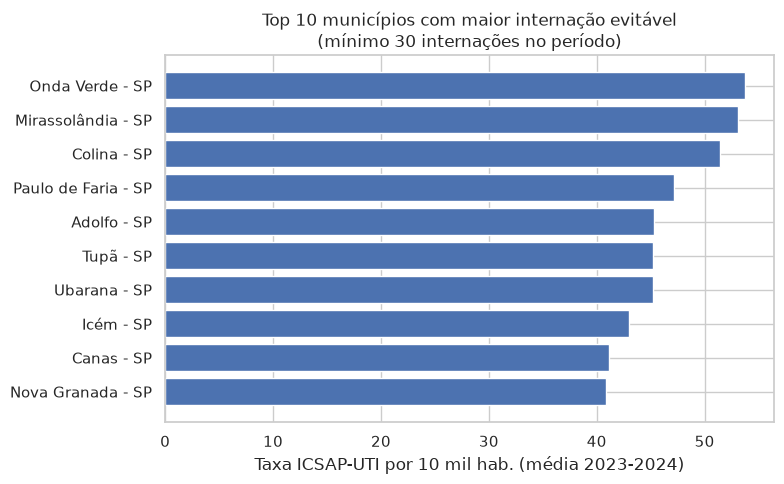

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

painel_top10 = pd.read_parquet(DATA_DIR / "painel_municipio_ano_sp_2022_2024.parquet")
painel_top10 = painel_top10[painel_top10["ano"].isin([2023, 2024])].copy()
painel_top10["taxa_icsap_uti_10k"] = (
    painel_top10["qtd_internacoes_icsap_uti"] / painel_top10["populacao"] * 10000
)

por_municipio_top10 = painel_top10.groupby(["municipio_6", "nome_municipio"]).agg(
    taxa_icsap_uti_10k=("taxa_icsap_uti_10k", "mean"),
    populacao=("populacao", "mean"),
    qtd_internacoes_icsap_uti=("qtd_internacoes_icsap_uti", "sum"),
).reset_index()

PISO_VOLUME = 30  # minimo de internacoes ICSAP-UTI no periodo, pra taxa nao ser so ruido
elegiveis = por_municipio_top10[por_municipio_top10["qtd_internacoes_icsap_uti"] >= PISO_VOLUME]
top10 = elegiveis.sort_values("taxa_icsap_uti_10k", ascending=False).head(10)

print(f"Municípios elegíveis (>= {PISO_VOLUME} internações ICSAP-UTI no período): {len(elegiveis)} de {len(por_municipio_top10)}")
print(top10[["nome_municipio", "taxa_icsap_uti_10k", "populacao", "qtd_internacoes_icsap_uti"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["nome_municipio"][::-1], top10["taxa_icsap_uti_10k"][::-1], color="#4C72B0")
ax.set_xlabel("Taxa ICSAP-UTI por 10 mil hab. (média 2023-2024)")
ax.set_title(f"Top 10 municípios com maior internação evitável\n(mínimo {PISO_VOLUME} internações no período)")
plt.tight_layout()
plt.show()

**Resultado**: com o piso de volume aplicado, a lista fica dominada por município de porte pequeno a médio do interior (não a região metropolitana da capital), com Tupã entre eles — mesmo município já identificado como polo regional isolado na etapa 7. O padrão é razoavelmente estável: subir o piso pra 50 ou 100 internações não muda a composição geral da lista, só troca alguns nomes na borda.

**Insight**: a lista sem o piso de volume (município de 2 a 5 mil habitantes) seria estatisticamente enganosa — pareceria ranking de "pior desempenho" quando é, em boa parte, ruído de denominador pequeno. Com o piso, o achado é consistente com a tese central do projeto: município pequeno e afastado de um polo regional concentra a pior taxa de internação evitável.

**Impacto**: dá pra gestor de saúde estadual um ponto de partida concreto — não "invista mais em todo lugar", mas "esses 10 municípios específicos merecem diagnóstico local prioritário".

**Decisão**: usar esta lista (recalculada com dado mais recente sempre que o painel for atualizado, sempre com o piso de volume) como ponto de partida de uma rodada de diagnóstico local nesses municípios — provavelmente problema de acesso à atenção especializada de referência, não de gasto per capita (ver seção 11.1).


**Indicador — Sobrecarga sazonal por grupo CSAP** (reaproveita a etapa 6, sem código novo): mede a variação percentual entre o mês de pico e o mês de vale de cada grupo CSAP. Pulmonar tem a maior sobrecarga do painel (quase 70% de variação, pico no outono/inverno), insuficiência cardíaca puxa pra mesma direção, e angina é o único grupo com pico no verão — mas é o sinal mais fraco e com poucos casos por mês pra confiar. Serve de gatilho pro gestor: sazonalidade acima de um corte vira aviso de reforço de leito/equipe pro grupo correspondente antes da estação de pico, métrica que alimenta a alocação sazonal via Select AI do roadmap pós entrega da sprint 4.


### Leitura da etapa 11

- Cinco insights, dois já cobertos por dados existentes (SIOPS, Efeito Esponja) e três com código novo nesta seção (viés de seleção, PSM municipal + curva de degradação, limitações do modelo de ML).
- Padrão que atravessa a seção inteira: toda vez que o dado ingênuo pareceu contradizer a tese central, a explicação da contradição virou o achado real — fragmentação de dado (11.1), viés de seleção (11.2), limite do tipo de dado (11.4).
- Nenhum achado com significância estatística fraca (PSM municipal, p=0,55) é apresentado como prova isolada — sempre como corroboração de uma evidência mais forte já estabelecida.

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

- Próximos passos do projetos (roadmap pós sprint 4, implementações para a banca final):

- Aplicar a decisão da seção 11.6 na arquitetura de regulação proposta, e granularizar a geolocalização por CEP
- pseudonimizar (hash irreversível, mesma técnica já pensada pra chave de paciente) um conjunto maior de dado sensível, principalmente perfil do paciente e dado de cidade, pra tirar o máximo de dado possível sem esbarrar em LGPD e alimentar tanto o modelo de reinternação quanto o Select AI.
- (já desenhado, não é ideia solta): o achado de sazonalidade da etapa 6, pulmonar e insuficiência cardíaca concentrados no outono/inverno, hipótese inicial de calor refutada pelos próprios dados e pela literatura específica de São Paulo, vira feature do modelo de reinternação e insumo de uma camada de recomendação em Select AI, sugerindo alocação de recurso hospitalar por grupo CSAP de acordo com a estação, direto pro gestor via ADB/APEX.
- Incluir dado de cobertura de atenção primária (SIA/SUS) por município/região, hoje ausente do dataset (a própria etapa 7 já registra isso: "ficou fora do escopo desde o início"). Serve pra testar de fato a hipótese de que região com mais cobertura de atenção primária interna menos por condição evitável, hoje sustentada só por consistência, não por prova.

- Mirando a banca final (15/09): capturar o SIOPS aberto por subfunção (Anexo 12 do RREO, Lei Complementar 141/2012, publicação bimestral obrigatória — 10.301 Atenção Básica, 10.302 Assistência Hospitalar e Ambulatorial, entre outras), hoje não integrado ao pipeline (só o total ASPS é capturado). Com isso, dá pra testar a versão fina da hipótese do Paradoxo do Investimento (etapa 10/11.1): separar o efeito de investimento em atenção primária do resto do gasto em saúde, em vez de usar só o total ASPS como proxy.

## 12. O Machine Learning explicado

A seção 11.4 apresentou o modelo pelo resultado (ROC-AUC e limitação do dado). Esta seção fecha o passo 12 do Guia, que pede a construção: o que o modelo faz, com que variáveis, como os dados foram preparados e divididos, e por que este algoritmo e não outro.

| Elemento | O que foi feito |
|---|---|
| **Problema** | Classificação binária: prever se um paciente internado com UTI vai reinternar dentro de 30 dias. Escolhida entre as três opções do Guia (previsão, classificação, clustering) porque reinternação em 30 dias já existe no dado, é o indicador clássico de falha de continuidade do cuidado, e conversa direto com a tese do projeto: reinternação precoce é o outro lado da mesma moeda da internação evitável. |
| **Variáveis de entrada** | 4 numéricas (`val_tot`, `dias_perm`, `despesa_paga_per_capita` do município, `tempo_viagem_minutos` até o polo) e 5 categóricas (`idade_faixa`, `sexo`, `grupo_csap_nome`, `dia_semana`, `feriado`). Depois do one-hot, 49 colunas. |
| **Variável-alvo** | `reinternacao_30d`, booleana. Prevalência de 14,92% no conjunto de teste. |
| **Preparação** | One-hot com `drop_first=True` nas categóricas; `align` entre treino e teste pra garantir as mesmas colunas dos dois lados (categoria que só aparece num ano viraria coluna fantasma sem isso); `grupo_csap_nome` nulo preenchido com `Nao_ICSAP`, que é o nulo por design já tratado na etapa 2.0; linhas sem alvo removidas. Nenhum escalonamento, porque árvore não precisa (ver Justificativa). |
| **Divisão dos dados** | Split **temporal**, não aleatório: treina em 2023, testa em 2024. Split aleatório colocaria internação do mesmo período dos dois lados e inflaria a métrica. O uso real do modelo é sempre prever o ano seguinte, então o teste tem que imitar isso. |
| **Algoritmo** | `XGBClassifier`, 100 árvores, profundidade 6, learning rate 0,1, `scale_pos_weight` = 5,76 (razão negativo/positivo no treino). |
| **Justificativa** | Testada, não afirmada. A célula abaixo roda a mesma matriz de features e o mesmo split em quatro algoritmos de famílias diferentes. |
| **Resultado** | Seção 11.4 (o achado) e seção 13 (as métricas). |
| **Métrica** | Seção 13. |

**Por que quatro modelos e não um.** "Escolhi XGBoost porque é bom em dado tabular" é justificativa de decoreba: vale igual antes e depois de olhar o dado. A justificativa honesta é comparativa — rodar do piso teórico até o modelo escolhido, com tudo o mais igual, e mostrar quanto cada degrau da escada acrescenta de fato.

**Tradução do código**: "monta a mesma matriz de features e o mesmo split da seção 11.4, e treina quatro algoritmos em cima dela, do chute proporcional ao XGBoost, imprimindo o ROC-AUC e o tempo de treino de cada um".

In [59]:
import time
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Mesma matriz de features, mesmo split temporal e mesmo tratamento de desbalanceamento
# da secao 11.4. A UNICA coisa que muda entre as linhas da tabela e o algoritmo.
X_treino = pd.get_dummies(df_ml[mask_treino][features_cat + features_num],
                          columns=features_cat, drop_first=True)
X_teste = pd.get_dummies(df_ml[mask_teste][features_cat + features_num],
                         columns=features_cat, drop_first=True)
X_treino, X_teste = X_treino.align(X_teste, join="outer", axis=1, fill_value=0)
y_treino = df_ml[mask_treino][target].astype(int)
y_teste = df_ml[mask_teste][target].astype(int)
peso_classe = (len(y_treino) - y_treino.sum()) / y_treino.sum()

print(f"{X_treino.shape[1]} colunas depois do one-hot | treino (2023) = {len(y_treino):,} | teste (2024) = {len(y_teste):,}")
print(f"Prevalencia de reinternacao em 30 dias no teste: {y_teste.mean():.2%}")
print(f"scale_pos_weight (razao negativo/positivo no treino): {peso_classe:.2f}")
print()

def avaliar(nome, modelo, escalona=False):
    inicio = time.time()
    if escalona:
        escala = StandardScaler().fit(X_treino.astype(float))
        modelo.fit(escala.transform(X_treino.astype(float)), y_treino)
        proba = modelo.predict_proba(escala.transform(X_teste.astype(float)))[:, 1]
    else:
        modelo.fit(X_treino, y_treino)
        proba = modelo.predict_proba(X_teste)[:, 1]
    segundos = time.time() - inicio
    auc = roc_auc_score(y_teste, proba)
    print(f"{nome:42s} ROC-AUC = {auc:.3f}   (treino: {segundos:.1f}s)")
    return modelo, proba, auc

print("Escada de modelos, do mais simples ao escolhido:")
avaliar("Chute proporcional (piso teorico)",
        DummyClassifier(strategy="stratified", random_state=42))
avaliar("Regressao logistica (baseline linear)",
        LogisticRegression(max_iter=1000, class_weight="balanced"), escalona=True)
avaliar("Arvore de decisao unica (profundidade 6)",
        DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=42))
modelo_xgb, proba_xgb, auc_xgb = avaliar(
    "XGBoost (o escolhido, secao 11.4)",
    xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                      scale_pos_weight=peso_classe, random_state=42, n_jobs=-1))

49 colunas depois do one-hot | treino (2023) = 267,940 | teste (2024) = 267,574
Prevalencia de reinternacao em 30 dias no teste: 14.92%
scale_pos_weight (razao negativo/positivo no treino): 5.76

Escada de modelos, do mais simples ao escolhido:
Chute proporcional (piso teorico)          ROC-AUC = 0.500   (treino: 0.0s)
Regressao logistica (baseline linear)      ROC-AUC = 0.619   (treino: 1.6s)
Arvore de decisao unica (profundidade 6)   ROC-AUC = 0.633   (treino: 0.8s)
XGBoost (o escolhido, secao 11.4)          ROC-AUC = 0.664   (treino: 3.0s)


**Leitura da escada:**

- **Chute proporcional = 0,500.** É o piso, por construção. Serve de controle da própria avaliação: se esse número não desse 0,5, haveria erro em algum lugar da montagem do teste.
- **Regressão logística = 0,619.** O baseline linear já captura a maior parte do sinal disponível. É contra esse número que todo o resto tem que se justificar, não contra o 0,5.
- **Árvore de decisão única = 0,633.** Ganha 0,014 sobre a logística. Isso já diz que existe não-linearidade e interação entre as variáveis: uma árvore captura "idade alta E permanência longa" de um jeito que a logística só capturaria com termo de interação escrito na mão.
- **XGBoost = 0,664.** Ganha 0,045 sobre a logística e 0,031 sobre a árvore única, com 3 segundos de treino. É o degrau que justifica a escolha, e o ganho vem de combinar muitas árvores rasas, cada uma corrigindo o erro da anterior.

**A justificativa do algoritmo, então, tem duas partes:**

**1. Por que XGBoost.** Dado tabular, mistura de categórica e numérica, alvo desbalanceado (1 positivo pra 5,76 negativos, tratado com `scale_pos_weight`), relação claramente não-linear pelo salto da logística pra árvore, e nenhuma necessidade de escalonar variável. É o cenário em que gradient boosting é o padrão da área, e a escada acima mostra que aqui ele de fato entrega o melhor resultado, não só na teoria.

**2. O que a escada prova além disso, e que é o achado mais importante desta seção.** Quatro famílias de algoritmo, do chute ao gradient boosting, e o teto fica em 0,664. Isso sustenta com evidência a afirmação que a seção 11.4 fazia sozinha: **o limite é do tipo de dado, não do ajuste do modelo**. Se fosse problema de modelagem, a distância entre a logística e o XGBoost seria muito maior. Trocar de algoritmo compra 0,045 de ROC-AUC; o que compraria mais é variável clínica (gravidade, comorbidade, exame), e o SIH-SUS não tem nenhuma.

**Nota de reprodutibilidade**: esta célula foi executada num ambiente com versão diferente de biblioteca numérica, o que move o ROC-AUC do XGBoost na terceira casa (0,664 aqui contra 0,667 na seção 11.4). Mesmo dado, mesma semente, mesma receita, nenhuma leitura deste notebook depende dessa diferença.

## 13. Métricas e interpretação do modelo

O Guia pede que a métrica seja escolhida de acordo com o tipo de problema e que o valor obtido seja interpretado, não só exibido. A seção 11.4 reportou só ROC-AUC. Esta seção explica por que essa foi a métrica de cabeçalho e por que ela sozinha não basta aqui.

**Por que ROC-AUC como métrica principal.** O problema é classificação binária desbalanceada (14,92% de positivos). Acurácia está descartada de saída: um modelo que dissesse "ninguém reinterna" acertaria 85,1% dos casos e seria completamente inútil. O ROC-AUC mede capacidade de **ordenar** — a chance de o modelo dar nota maior pra um paciente que reinternou do que pra um que não reinternou — e não depende de escolher um ponto de corte. É por isso que ele é a métrica certa pra comparar modelos entre si (foi o que a seção 12 fez) e pra comparar populações com prevalência diferente.

**Por que ela não basta.** ROC-AUC não diz o que acontece quando alguém usa o modelo pra decidir alguma coisa, porque decidir exige um corte. É aí que entram precisão, recall e F1, calculados abaixo no corte de 0,5.

- **Precisão**: de quem o modelo sinaliza, quantos reinternam de fato. É o custo do falso positivo.
- **Recall**: das reinternações que aconteceram, quantas o modelo pegou. É o custo do falso negativo.
- **F1**: a média harmônica das duas, útil pra resumir o equilíbrio num número só.

**Tradução do código**: "aplica o corte de 0,5 na probabilidade prevista, monta a matriz de confusão, e reporta as quatro métricas junto com quantas pessoas o modelo sinalizaria na prática e quanto isso é melhor do que chutar na prevalência".

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def painel_de_metricas(y_verdadeiro, probabilidade, nome, corte=0.5):
    predito = (probabilidade >= corte).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_verdadeiro, predito).ravel()
    prevalencia = y_verdadeiro.mean()
    precisao = precision_score(y_verdadeiro, predito)
    print(f"--- {nome}")
    print(f"  N = {len(y_verdadeiro):,} | reinternacoes reais = {int(y_verdadeiro.sum()):,} "
          f"| prevalencia = {prevalencia:.2%}")
    print(f"  ROC-AUC   {roc_auc_score(y_verdadeiro, probabilidade):.3f}")
    print(f"  Precisao  {precisao:.3f}   (de cada 100 sinalizados, {precisao*100:.0f} reinternam de fato)")
    print(f"  Recall    {recall_score(y_verdadeiro, predito):.3f}   "
          f"(pega {recall_score(y_verdadeiro, predito)*100:.0f}% das reinternacoes que existiram)")
    print(f"  F1        {f1_score(y_verdadeiro, predito):.3f}")
    print(f"  Ganho sobre chutar na prevalencia: {precisao/prevalencia:.2f}x")
    print(f"  Sinalizados pelo modelo: {tp+fp:,} de {len(y_verdadeiro):,} ({(tp+fp)/len(y_verdadeiro):.1%} da base)")
    print(f"  Matriz de confusao: VN={tn:,} | FP={fp:,} | FN={fn:,} | VP={tp:,}")
    print()

painel_de_metricas(y_teste, proba_xgb, "Populacao inteira (o numero de cabecalho da secao 11.4)")

# Mesmo modelo, mesma receita, so na populacao onde reinternar e fisicamente possivel
X_sub_treino = pd.get_dummies(df_sub[df_sub["ano"] == 2023][features_cat + features_num],
                              columns=features_cat, drop_first=True)
X_sub_teste = pd.get_dummies(df_sub[df_sub["ano"] == 2024][features_cat + features_num],
                             columns=features_cat, drop_first=True)
X_sub_treino, X_sub_teste = X_sub_treino.align(X_sub_teste, join="outer", axis=1, fill_value=0)
y_sub_treino = df_sub[df_sub["ano"] == 2023][target].astype(int)
y_sub_teste = df_sub[df_sub["ano"] == 2024][target].astype(int)
peso_sub = (len(y_sub_treino) - y_sub_treino.sum()) / y_sub_treino.sum()

modelo_sub = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                               scale_pos_weight=peso_sub, random_state=42, n_jobs=-1)
modelo_sub.fit(X_sub_treino, y_sub_treino)
proba_sub = modelo_sub.predict_proba(X_sub_teste)[:, 1]

painel_de_metricas(y_sub_teste, proba_sub, "So pacientes com mais de 1 internacao no periodo")

--- Populacao inteira (o numero de cabecalho da secao 11.4)
  N = 267,574 | reinternacoes reais = 39,912 | prevalencia = 14.92%
  ROC-AUC   0.664
  Precisao  0.215   (de cada 100 sinalizados, 22 reinternam de fato)
  Recall    0.654   (pega 65% das reinternacoes que existiram)
  F1        0.324
  Ganho sobre chutar na prevalencia: 1.44x
  Sinalizados pelo modelo: 121,113 de 267,574 (45.3% da base)
  Matriz de confusao: VN=132,641 | FP=95,021 | FN=13,820 | VP=26,092

--- So pacientes com mais de 1 internacao no periodo
  N = 91,485 | reinternacoes reais = 39,912 | prevalencia = 43.63%
  ROC-AUC   0.619
  Precisao  0.514   (de cada 100 sinalizados, 51 reinternam de fato)
  Recall    0.612   (pega 61% das reinternacoes que existiram)
  F1        0.559
  Ganho sobre chutar na prevalencia: 1.18x
  Sinalizados pelo modelo: 47,468 de 91,485 (51.9% da base)
  Matriz de confusao: VN=28,521 | FP=23,052 | FN=15,496 | VP=24,416



**Interpretação, população inteira** (a que gera o número de cabeçalho da seção 11.4):

- **Precisão 0,215.** De cada 100 pacientes que o modelo sinaliza como risco, cerca de 22 reinternam de fato. Contra uma prevalência de 14,92%, é um ganho de 1,44x sobre chutar. Ganho real, e modesto.
- **Recall 0,654.** O modelo pega 65% das reinternações que existiram. Perde 13.820 casos.
- **O custo desse recall está na matriz de confusão.** Pra capturar 26.092 reinternações, o modelo sinaliza 121.113 pacientes, ou seja, 45,3% da base inteira. Um sistema de priorização que marca quase metade dos pacientes como prioritários não prioriza nada.
- **F1 0,324** resume o desequilíbrio: recall razoável comprado com precisão baixa.

**Interpretação, população restrita** (só quem teve mais de uma internação no período):

- Precisão sobe pra 0,514 e F1 pra 0,559, o que à primeira vista parece um modelo melhor. Não é. **A prevalência subiu junto**, de 14,92% pra 43,63%, e o ganho sobre chutar na prevalência CAI de 1,44x pra 1,18x. É o caso didático de por que precisão e F1 não são comparáveis entre populações de prevalência diferente, e por que o ROC-AUC (que cai de 0,664 pra 0,619) é a leitura honesta das duas.
- **O detalhe que fecha o raciocínio**: as reinternações reais são exatamente as mesmas nas duas linhas, 39.912. Não podia ser diferente, porque quem reinterna tem, por definição, mais de uma internação no período. O recorte não remove nenhum caso positivo, remove só negativo fácil — e é por isso que o ROC-AUC cai. O modelo perde justamente os casos que ele acertava sem esforço.

**O que essas métricas mudam na decisão da seção 11.4.** Nada, e esse é o ponto: elas sustentam a mesma decisão com evidência mais forte e mais fácil de explicar. A recomendação de não usar o score bruto pra priorizar leito em tempo real estava apoiada só na direção errada que o modelo aprendeu (viés de distância). Agora tem um segundo motivo, independente do primeiro: no corte que aproveita melhor o modelo, ele marcaria 45% dos pacientes, com 21,5% de precisão. Isso é suficiente pra sinalização populacional e insuficiente pra decisão individual — exatamente o que a seção 11.4 concluiu por outro caminho.

## 16. Conclusão

**O objetivo.** Este notebook começou com uma pergunta de gestão em saúde: quanto do gasto público em saúde em São Paulo está de fato evitando internação com UTI, e onde essa lógica falha. Pra responder, percorreu o caminho completo do Guia — AED em 8 etapas sobre o `dataset_unificado_sp_2022_2024.parquet` (463.299 linhas agregadas, 813.422 internações reais, 645 municípios, 2022-2024), preparação estatística sobre o painel município-ano com SIOPS, teste de hipótese, e um módulo de Machine Learning.

**O que a AED encontrou.** 18,7% das internações com UTI em SP são ICSAP, proporção estável nos três anos. Três famílias de nulo, cada uma com causa diferente e nenhuma tratada por regra geral: a maior (83%) é nulo por design, e as duas reais foram classificadas por mecanismo (MAR nas duas, MCAR descartado por teste e não por suposição), padrão (monotônico, verificado), intenção e visibilidade. Nenhuma imputação foi feita, e a decisão de manter nulo está documentada com o motivo. Outlier seguiu a mesma filosofia: 90,4% dos município-ano não estouram fence em nenhuma das 5 métricas centrais, a maior parte do que estoura se explica por número pequeno de internação, e nenhuma linha foi removida. Entre as três dimensões testadas — capacidade instalada, mês e região — a geográfica é de longe a mais explicativa: a taxa ICSAP mediana varia mais que o dobro entre as 11 Regiões Intermediárias do IBGE (7,65 a 17,41), contra 8-9% de variação sazonal no agregado e correlação máxima de -0,24 com capacidade instalada.

**O que a preparação estatística acrescentou.** Os dois grupos de comparação são não-normais por três sinais convergentes (assimetria positiva, curtose em excesso, outlier concentrado na cauda direita), o que roteou o teste pro não-paramétrico antes de qualquer resultado aparecer. E a decomposição entre-município x dentro-município adiantou o mecanismo do achado: a correlação de 0,125 entre investimento e taxa cai pra 0,034 quando se isola a variação dentro do mesmo município ao longo do tempo, enquanto o investimento per capita tem correlação de -0,645 com população. O confundidor por porte de município estava identificado **antes** do teste, não inventado depois pra explicar um resultado incômodo.

**O que o teste de hipótese respondeu.** A hipótese original do projeto não se confirmou: não há evidência de que investir mais por habitante reduza a internação evitável (Mann-Whitney, p = 0,9994). Na direção oposta o resultado é significativo e estável nos três cortes (mediana, tercil, quartil, p entre 0,0006 e 0,0078), e a checagem com o t de Welch chega ao mesmo p-valor até a terceira casa. O tamanho de efeito é pequeno nas duas escalas (r = 0,13 e d de Cohen = 0,254). A explicação não é que investir piore o desfecho: é o mesmo confundimento por porte já mapeado na etapa 9.5.

**O que o Machine Learning acrescentou.** Menos do que se esperava, e era exatamente isso que ele tinha a acrescentar. O modelo de reinternação em 30 dias chega a ROC-AUC de 0,664, e a escada de quatro algoritmos da seção 12 mostra que o teto é do tipo de dado e não do ajuste: a regressão logística sozinha já entrega 0,619, e o gradient boosting compra só mais 0,045. As métricas da seção 13 fecham o argumento: no corte de 0,5 o modelo sinalizaria 45,3% da base pra capturar 65% das reinternações, com 21,5% de precisão. Serve pra sinalização populacional, não serve pra decisão individual — e essa conclusão passou a estar sustentada por dois caminhos independentes, o viés de distância aprendido pelo modelo e a precisão no corte.

**Quais variáveis e indicadores se mostraram mais úteis**, em ordem de poder explicativo demonstrado neste notebook:

1. **Região Intermediária do IBGE** e **distância/tempo real até o polo regional**. Foi o recorte que mais separou município, e os 20 polos foram identificados de forma independente por dois métodos (capacidade instalada no SIH e geografia real de estrada), o que é a evidência mais forte deste notebook.
2. **Porte do município** (população, não gasto bruto). Não é interessante por si, é obrigatório como controle: qualquer indicador de investimento contra desfecho é enganoso sem ele.
3. **Taxa ICSAP-UTI por 10 mil habitantes com piso de volume**. Sem piso, é ruído de denominador pequeno; com piso de 30 internações no período, vira lista de prioridade utilizável.
4. **Sazonalidade por grupo CSAP**, nunca agregada. No agregado o sinal é fraco (8-9%); quebrado por grupo, pulmonar varia quase 70%.
5. **Investimento per capita do SIOPS**. Útil como variável, inútil como ranking isolado, pelo motivo do item 2.

**Limitações, sem maquiagem.**

- **Do dado.** O SIH-SUS é registro administrativo e não tem nenhuma variável clínica, o que é o teto do modelo da seção 11.4. O gap de cadastro do CNES-LT deixa `qtd_leitos_*` nulo em 10,7% do dataset e em 44% dos municípios do painel. O SIOPS capturado é o total ASPS, sem a abertura por subfunção que separaria atenção primária do resto do gasto. E não existe dado de cobertura de atenção primária (SIA) no escopo, o que significa que a tese central segue sustentada por consistência geográfica, não por prova.
- **Do método.** O desenho é transversal na prática: com só dois anos de SIOPS utilizável, a defasagem de um ano existe na construção do painel mas não sustenta leitura longitudinal. O PSM municipal da seção 11.3 corrobora a direção mas não fecha significância (p = 0,55), e por isso é tratado como corroboração e não como prova. A anonimização por chave aproximada sinaliza 0,38% de colisão suspeita.
- **Do escopo.** A base SIH-UTI só contém quem chegou a ser internado. Toda leitura a nível de paciente carrega esse condicionamento, e foi por causa dele que a seção 11.2 trocou a unidade de análise em vez de aceitar o resultado bruto.

**Próximos passos** (os mesmos da leitura da etapa 11, aqui reunidos):

- Capturar o SIOPS aberto por subfunção (Anexo 12 do RREO, LC 141/2012, publicação bimestral obrigatória) pra testar a versão fina da hipótese do Paradoxo do Investimento, separando atenção primária do resto do gasto.
- Incluir cobertura de atenção primária (SIA/SUS) por município e região, hoje ausente. É o dado que falta pra sair de consistência e chegar em teste.
- Aplicar a decisão da seção 11.6 na arquitetura de regulação proposta, granularizando a geolocalização por CEP.
- Pseudonimizar (hash irreversível, a mesma técnica já pensada pra chave de paciente) um conjunto maior de dado sensível, pra aproveitar o máximo possível sem esbarrar em LGPD.
- Transformar o achado de sazonalidade por grupo CSAP em feature do modelo de reinternação e em insumo de uma camada de recomendação de alocação sazonal via Select AI, entregue ao gestor por ADB/APEX.

E é aqui que a linha de raciocínio fecha. Os três achados centrais deste notebook — o Paradoxo do Investimento, o Viés do Sobrevivente e o teto do modelo — começaram como resultado que contrariava a expectativa. Nenhum dos três virou rodapé: os três viraram a conclusão, porque investigar **por que** o dado discordou foi o que produziu a informação de verdade. A entrega não é o código funcionando, é essa linha.

ps: obrigado de novo pelos capítulos 5 e 7, caro Grandioso Mestre Jedi. A Força continua com a gente, agora com t-statistic e tudo.
